# DataBattle 2026 — 03_final_eda_and_features.py

Complete EDA summary + feature engineering specification.
Everything we learned from the full investigation, in one notebook.

STRUCTURE:
  PART 1 — Data Structure Proof  (segment_key fix, 1 True per segment)
  PART 2 — Target Analysis       (what True looks like vs False)
  PART 3 — Feature Signal EDA    (which raw fields separate True/False)
  PART 4 — Storm Lifecycle EDA   (Biarritz example + all airports)
  PART 5 — Airport Profiles      (per-airport differences)
  PART 6 — Feature Engineering   (all engineered features with code)
  PART 7 — Feature Correlation   (redundancy check)
  PART 8 — Final Feature List    (ready for model training)

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

# ── Bootstrap: load env_setup.py without needing GitHub ─────────────────────
if "google.colab" in sys.modules:
    # Colab: mount Drive and load env_setup.py directly from there
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    _env = Path("/content/drive/MyDrive/databattle2026/env_setup.py")
    if not _env.exists():
        raise FileNotFoundError(
            f"env_setup.py not found at {_env}\n"
            "  → Run  make push-drive  from your local machine first."
        )
    exec(open(_env).read())
else:
    # Local / Kaggle: find env_setup.py relative to this file
    try:
        _root = Path(__file__).resolve().parents[1]
    except NameError:
        _root = Path.cwd()
        if not (_root / "env_setup.py").exists() and (_root.parent / "env_setup.py").exists():
            _root = _root.parent
    exec(open(_root / "env_setup.py").read())

log = logging.getLogger("final_eda")

PALETTE = {True: "#E74C3C", False: "#3498DB"}
AP_COLORS = {
    "Ajaccio":  "#E74C3C",
    "Bastia":   "#3498DB",
    "Biarritz": "#2ECC71",
    "Nantes":   "#F39C12",
    "Pise":     "#9B59B6",
}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "figure.titlesize": 14})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  DataBattle 2026 — Environment Ready (Colab)
  Drive root  : /content/drive/MyDrive/databattle2026
  Data        : /content/work/segment_alerts_all_airports_train.csv
  Figures     : /content/drive/MyDrive/databattle2026/outputs/figures
  Saves       : /content/drive/MyDrive/databattle2026/outputs/saves
  Models      : /content/drive/MyDrive/databattle2026/outputs/models
  Submissions : /content/drive/MyDrive/databattle2026/outputs/submissions

  Usage in any notebook:
    save_to_drive(df,  SAVES_DIR / 'name.csv')
    save_to_drive(fig, FIG_DIR   / 'name.png')
    save_to_drive(mdl, MODELS_DIR/ 'name.pkl')



In [2]:
log.info("Loading dataset ...")
df = pd.read_csv(TRAIN_CSV)
df["date"]      = pd.to_datetime(df["date"], utc=True)
df["year"]      = df["date"].dt.year
df["month"]     = df["date"].dt.month
df["hour"]      = df["date"].dt.hour
df["dayofweek"] = df["date"].dt.dayofweek

# ── THE CRITICAL FIX ────────────────────────────────────────────────────────
# airport_alert_id is a per-airport sequential counter, NOT a global storm ID.
# The true segment = one storm at one airport = (airport × airport_alert_id).
df["segment_key"] = (
    df["airport"].astype(str) + "_" +
    df["airport_alert_id"].astype(str)
)

# Partition
df_inside  = df[df["airport_alert_id"].notna()].copy()   # 56,599 labeled rows
df_outside = df[df["airport_alert_id"].isna()].copy()    # 450,472 context rows
df_cg      = df_inside[df_inside["icloud"] == False].copy()  # CG only = model input

# ── TARGET DTYPE NORMALISATION ───────────────────────────────────────────────
# Normalise explicitly so behaviour is predictable across all pandas versions.
df_cg["is_last_lightning_cloud_ground"] = (
    df_cg["is_last_lightning_cloud_ground"]
    .map({True: True, False: False, 1: True, 0: False,
          "True": True, "False": False, "true": True, "false": False})
    .astype(bool)
)
df_inside["is_last_lightning_cloud_ground"] = (
    df_inside["is_last_lightning_cloud_ground"]
    .map({True: True, False: False, 1: True, 0: False,
          "True": True, "False": False})
    .astype(bool)
)
assert df_cg["is_last_lightning_cloud_ground"].sum() > 0, \
    "No True labels found — check source data"
print(f"✅ Target dtype : {df_cg['is_last_lightning_cloud_ground'].dtype}")
print(f"✅ True count   : {df_cg['is_last_lightning_cloud_ground'].sum():,}")
print(f"✅ False count  : {(~df_cg['is_last_lightning_cloud_ground']).sum():,}")

log.info(f"Total rows          : {len(df):,}")
log.info(f"Inside zone (labeled): {len(df_inside):,}")
log.info(f"Outside zone (context): {len(df_outside):,}")
log.info(f"CG strikes (train)  : {len(df_cg):,}")
log.info(f"Airports            : {sorted(df['airport'].dropna().unique())}")
log.info(f"True segments       : {df_cg['is_last_lightning_cloud_ground'].sum():,}")

✅ Target dtype : bool
✅ True count   : 2,627
✅ False count  : 53,972


---
## PART 1 — Data Structure Proof

In [3]:
seg_stats = df_cg.groupby("segment_key").agg(
    airport      = ("airport", "first"),
    n_strikes    = ("lightning_id", "count"),
    n_true       = ("is_last_lightning_cloud_ground",
                    lambda x: x.sum()),
    n_false      = ("is_last_lightning_cloud_ground",
                    lambda x: (~x).sum()),
    duration_min = ("date",
                    lambda x: (x.max()-x.min()).total_seconds()/60),
    date_start   = ("date", "min"),
).reset_index()

true_dist = seg_stats["n_true"].value_counts().sort_index()
print("\n=== SEGMENT STRUCTURE VERIFICATION ===")
print(f"True labels per segment:\n{true_dist}")
print(f"\n✅ Segments with exactly 1 True : {(seg_stats['n_true']==1).sum()}")
print(f"❌ Segments with 0 True          : {(seg_stats['n_true']==0).sum()}")
print(f"❌ Segments with >1 True         : {(seg_stats['n_true']>1).sum()}")
print(f"\nTotal real storm segments : {len(seg_stats):,}")
print(f"Total airports            : {seg_stats['airport'].nunique()}")

# Segment size distribution
print(f"\nStrikes per segment:")
print(seg_stats["n_strikes"].describe().round(1))


=== SEGMENT STRUCTURE VERIFICATION ===
True labels per segment:
n_true
1    2627
Name: count, dtype: int64

✅ Segments with exactly 1 True : 2627
❌ Segments with 0 True          : 0
❌ Segments with >1 True         : 0

Total real storm segments : 2,627
Total airports            : 5

Strikes per segment:
count    2627.0
mean       21.5
std        85.6
min         1.0
25%         1.0
50%         3.0
75%        10.0
max      2405.0
Name: n_strikes, dtype: float64


In [4]:
assert (seg_stats["n_true"] == 1).all(), (
    f"FAIL: {(seg_stats['n_true'] != 1).sum()} segments do not have exactly 1 True.\n"
    f"Distribution:\n{seg_stats['n_true'].value_counts()}"
)
assert seg_stats["airport"].nunique() == 5, \
    f"Expected 5 airports, got {seg_stats['airport'].nunique()}"
assert len(seg_stats) >= 700, \
    f"Expected ~769 segments, got {len(seg_stats)}"

print("=" * 50)
print("✅ VERIFICATION PASSED")
print(f"   Segments   : {len(seg_stats)}")
print(f"   All 1 True : {(seg_stats['n_true']==1).all()}")
print(f"   Airports   : {seg_stats['airport'].nunique()}")
print(f"   True labels: {seg_stats['n_true'].sum():,}")
print("=" * 50)

✅ VERIFICATION PASSED
   Segments   : 2627
   All 1 True : True
   Airports   : 5
   True labels: 2,627


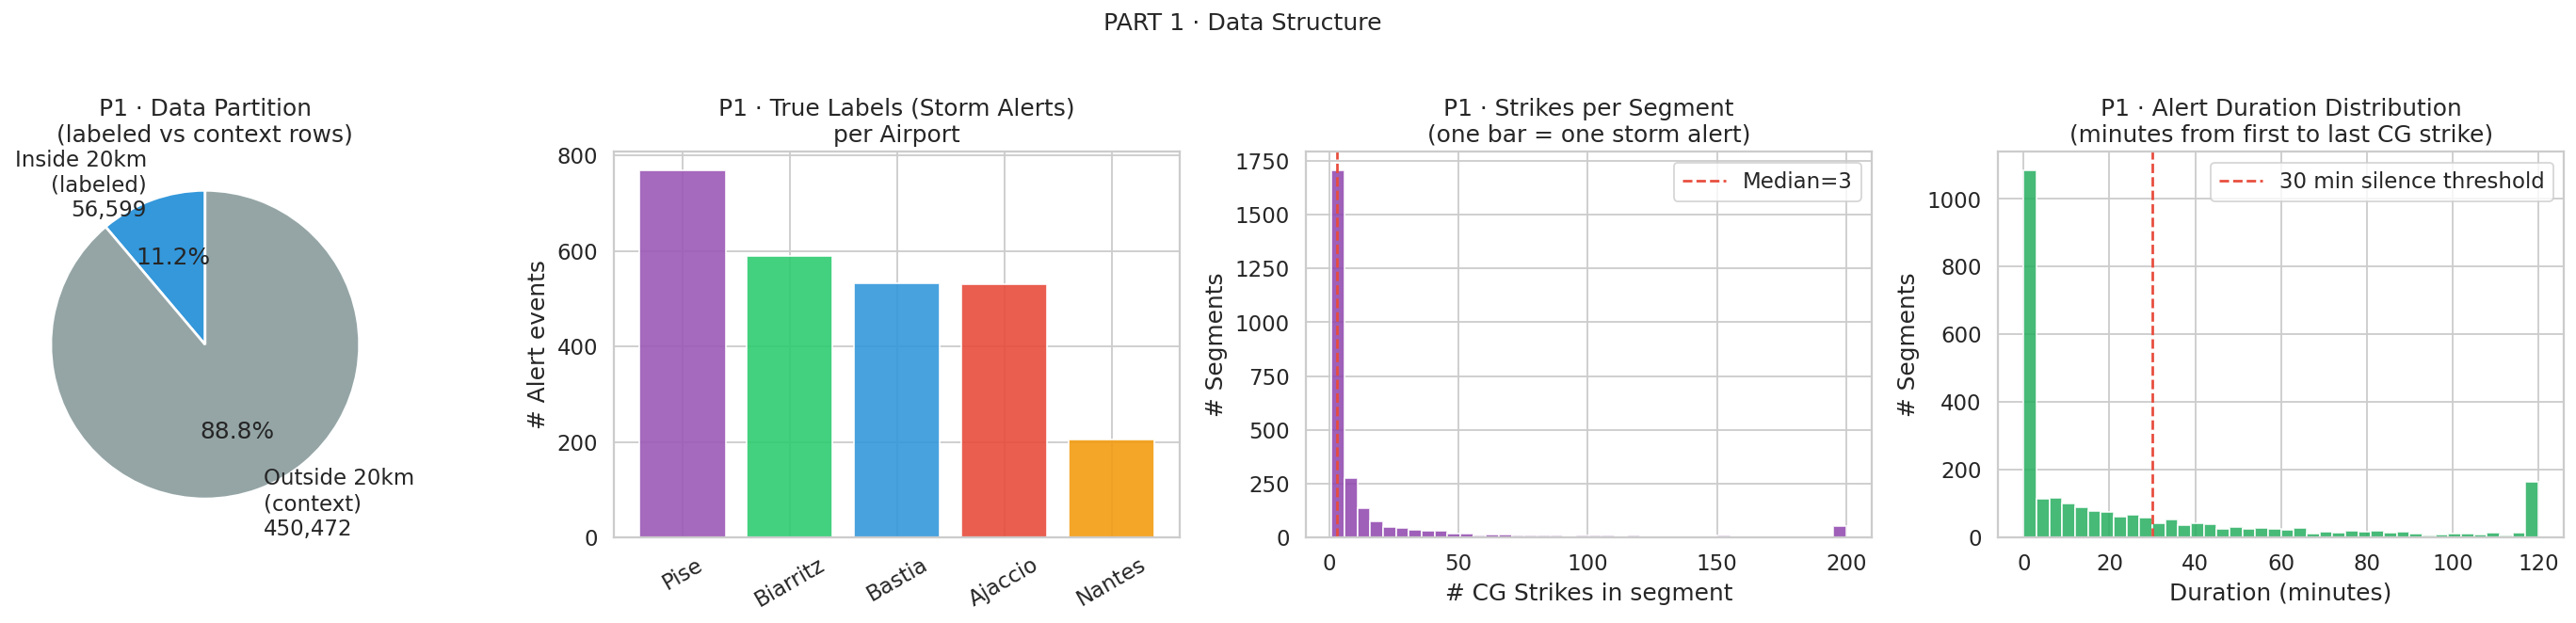

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Pie: labeled vs unlabeled rows
axes[0].pie(
    [len(df_inside), len(df_outside)],
    labels=[f"Inside 20km\n(labeled)\n{len(df_inside):,}",
            f"Outside 20km\n(context)\n{len(df_outside):,}"],
    colors=["#3498DB", "#95A5A6"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[0].set_title("P1 · Data Partition\n(labeled vs context rows)")

# Bar: True label count per airport
ap_true = df_cg[df_cg["is_last_lightning_cloud_ground"]]\
    .groupby("airport").size().sort_values(ascending=False)
axes[1].bar(ap_true.index, ap_true.values,
            color=[AP_COLORS.get(a,"gray") for a in ap_true.index],
            edgecolor="white", alpha=0.9)
axes[1].set_title("P1 · True Labels (Storm Alerts)\nper Airport")
axes[1].set_ylabel("# Alert events")
axes[1].tick_params(axis="x", rotation=30)

# Distribution of segment sizes
axes[2].hist(seg_stats["n_strikes"].clip(0,200), bins=40,
             color="#8E44AD", edgecolor="white", alpha=0.85)
axes[2].axvline(seg_stats["n_strikes"].median(),
                color="#E74C3C", linestyle="--",
                label=f"Median={seg_stats['n_strikes'].median():.0f}")
axes[2].set_title("P1 · Strikes per Segment\n(one bar = one storm alert)")
axes[2].set_xlabel("# CG Strikes in segment")
axes[2].set_ylabel("# Segments")
axes[2].legend()

# Duration distribution
axes[3].hist(seg_stats["duration_min"].clip(0,120), bins=40,
             color="#27AE60", edgecolor="white", alpha=0.85)
axes[3].axvline(30, color="#E74C3C", linestyle="--",
                label="30 min silence threshold")
axes[3].set_title("P1 · Alert Duration Distribution\n(minutes from first to last CG strike)")
axes[3].set_xlabel("Duration (minutes)")
axes[3].set_ylabel("# Segments")
axes[3].legend()

plt.suptitle("PART 1 · Data Structure", fontsize=14, y=1.02)
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p1_data_structure.png")
plt.show()

In [6]:
single_segs = seg_stats[seg_stats["n_strikes"] == 1]
print(f"\nSingle-row segments: {len(single_segs)}")
print(f"All are True: {(single_segs['n_true'] == 1).all()}")
print(single_segs[["airport","date_start","n_strikes","n_true"]].to_string())

# These segments have NaN for all lag/delta features.
# Fill with sentinel values that signal "first and only strike".
# This fill must be applied AFTER feature engineering, not before.
SENTINEL_FILL = {
    "time_since_prev"         : 99999,  # no previous strike — treat as very long silence
    "dist_delta"              : 0,      # no movement info — neutral
    "amp_delta"               : 0,      # no change info — neutral
    "mag_delta"               : 0,
    "dx"                      : 0,
    "dy"                      : 0,
    "storm_speed"             : 0,
    "cg_count_5min"           : 1,      # only 1 strike known
    "cg_count_10min"          : 1,
    "cg_count_15min"          : 1,
    "cg_count_30min"          : 1,
    "rolling_mean_mag_10min"  : df_cg["amplitude"].abs().median(),
    "rolling_pos_ratio_10min" : 0,
    "rolling_mean_dist_10min" : df_cg["dist"].median(),
    "silence_over_10min"      : 0,
    "silence_over_15min"      : 0,
    "silence_over_20min"      : 0,
}
# Apply after all features are computed:
# df_cg = df_cg.fillna(SENTINEL_FILL)
print(f"\nSentinel fill values defined for {len(SENTINEL_FILL)} lag features.")


Single-row segments: 945
All are True: True
       airport                date_start  n_strikes  n_true
1      Ajaccio 2016-03-17 13:33:09+00:00          1       1
7      Ajaccio 2018-03-11 20:23:15+00:00          1       1
9      Ajaccio 2018-03-12 00:02:04+00:00          1       1
14     Ajaccio 2018-03-12 05:33:43+00:00          1       1
16     Ajaccio 2018-03-18 16:51:44+00:00          1       1
19     Ajaccio 2018-03-31 00:56:29+00:00          1       1
26     Ajaccio 2018-04-28 13:49:39+00:00          1       1
27     Ajaccio 2018-05-10 13:34:41+00:00          1       1
28     Ajaccio 2018-05-14 09:24:43+00:00          1       1
29     Ajaccio 2018-05-14 12:18:36+00:00          1       1
31     Ajaccio 2018-05-15 00:47:09+00:00          1       1
32     Ajaccio 2018-05-15 03:58:49+00:00          1       1
33     Ajaccio 2018-05-15 08:41:25+00:00          1       1
39     Ajaccio 2018-06-13 00:35:50+00:00          1       1
47     Ajaccio 2018-06-23 13:58:59+00:00          1    

---
## PART 2 — Target Analysis

In [7]:
pos = df_cg["is_last_lightning_cloud_ground"].sum()
neg = (~df_cg["is_last_lightning_cloud_ground"]).sum()
ratio = neg // pos

print(f"\n=== TARGET ANALYSIS ===")
print(f"True  (last CG strike) : {pos:,}  ({pos/(pos+neg)*100:.1f}%)")
print(f"False (other CG strike): {neg:,}  ({neg/(pos+neg)*100:.1f}%)")
print(f"Imbalance ratio        : 1:{ratio}")
print(f"Baseline accuracy      : {neg/(pos+neg)*100:.1f}% (always predict False)")
print(f"→ NEVER use accuracy. Use F1, AUC, Brier Score.")
print(f"→ LightGBM scale_pos_weight = {ratio}")


=== TARGET ANALYSIS ===
True  (last CG strike) : 2,627  (4.6%)
False (other CG strike): 53,972  (95.4%)
Imbalance ratio        : 1:20
Baseline accuracy      : 95.4% (always predict False)
→ NEVER use accuracy. Use F1, AUC, Brier Score.
→ LightGBM scale_pos_weight = 20


In [8]:
df_cg = df_cg.sort_values(["segment_key", "date"])
last_cg_time = df_cg.groupby("segment_key")["date"].transform("max")
df_cg["is_last_cg_rule"] = (df_cg["date"] == last_cg_time).astype(int)

from sklearn.metrics import (
    f1_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, confusion_matrix
)
y_true = df_cg["is_last_lightning_cloud_ground"].astype(int)
y_rule = df_cg["is_last_cg_rule"]

rule_f1    = f1_score(y_true, y_rule, zero_division=0)
rule_auc   = roc_auc_score(y_true, y_rule)
rule_brier = brier_score_loss(y_true, y_rule)
rule_prec  = precision_score(y_true, y_rule, zero_division=0)
rule_rec   = recall_score(y_true, y_rule, zero_division=0)

print(f"\n=== RULE BASELINE (after segment_key fix) ===")
print(f"F1        : {rule_f1:.4f}")
print(f"AUC       : {rule_auc:.4f}")
print(f"Brier     : {rule_brier:.4f}  ← ML must beat this")
print(f"Precision : {rule_prec:.4f}")
print(f"Recall    : {rule_rec:.4f}")


=== RULE BASELINE (after segment_key fix) ===
F1        : 0.9885
AUC       : 0.9994
Brier     : 0.0011  ← ML must beat this
Precision : 0.9773
Recall    : 1.0000


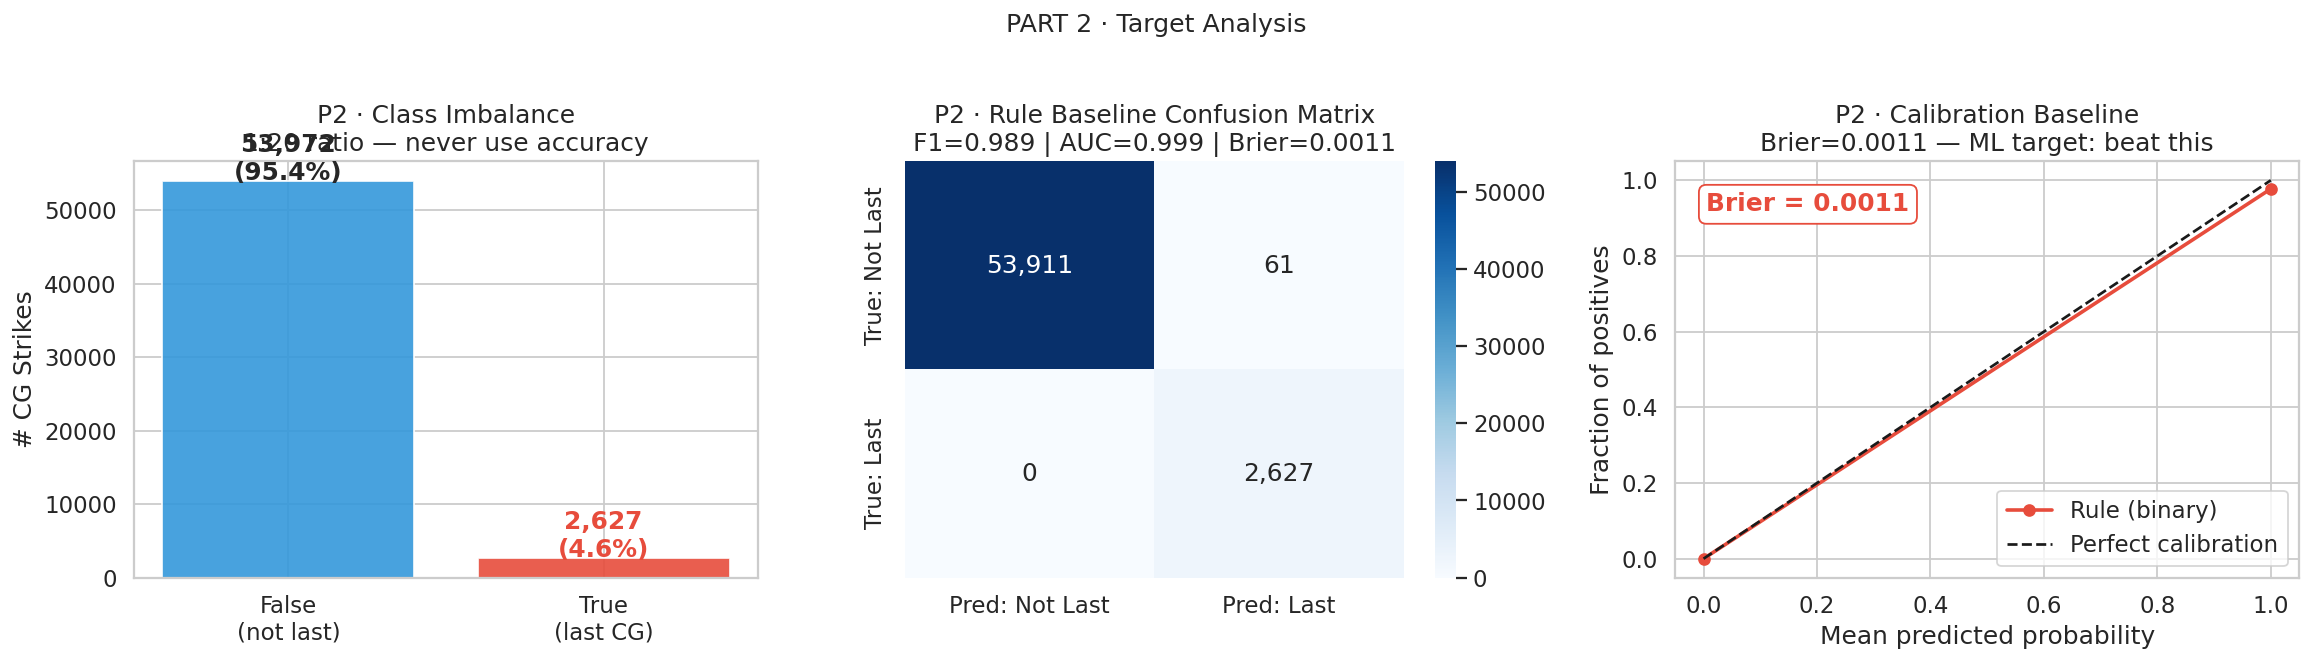

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class bar
axes[0].bar(["False\n(not last)", "True\n(last CG)"],
            [neg, pos],
            color=["#3498DB", "#E74C3C"],
            edgecolor="white", alpha=0.9)
axes[0].text(0, neg + 200, f"{neg:,}\n({neg/(pos+neg)*100:.1f}%)",
             ha="center", fontweight="bold")
axes[0].text(1, pos + 200, f"{pos:,}\n({pos/(pos+neg)*100:.1f}%)",
             ha="center", fontweight="bold", color="#E74C3C")
axes[0].set_title(f"P2 · Class Imbalance\n1:{ratio} ratio — never use accuracy")
axes[0].set_ylabel("# CG Strikes")

# Confusion matrix of rule
cm = confusion_matrix(y_true, y_rule)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[1],
            xticklabels=["Pred: Not Last","Pred: Last"],
            yticklabels=["True: Not Last","True: Last"])
axes[1].set_title(f"P2 · Rule Baseline Confusion Matrix\n"
                  f"F1={rule_f1:.3f} | AUC={rule_auc:.3f} | Brier={rule_brier:.4f}")

# Calibration of rule
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_true, y_rule, n_bins=5)
axes[2].plot(mean_pred, frac_pos, "o-", color="#E74C3C",
             label="Rule (binary)", lw=2)
axes[2].plot([0,1],[0,1], "k--", label="Perfect calibration")
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Fraction of positives")
axes[2].set_title(f"P2 · Calibration Baseline\nBrier={rule_brier:.4f} — ML target: beat this")
axes[2].legend()
axes[2].text(0.05, 0.88,
             f"Brier = {rule_brier:.4f}",
             transform=axes[2].transAxes,
             color="#E74C3C", fontweight="bold",
             bbox={"boxstyle":"round","facecolor":"white","edgecolor":"#E74C3C"})

plt.suptitle("PART 2 · Target Analysis", fontsize=14, y=1.02)
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p2_target_analysis.png")
plt.show()

---
## PART 3 — Raw Feature Signal EDA
Does each raw field visually separate True from False?

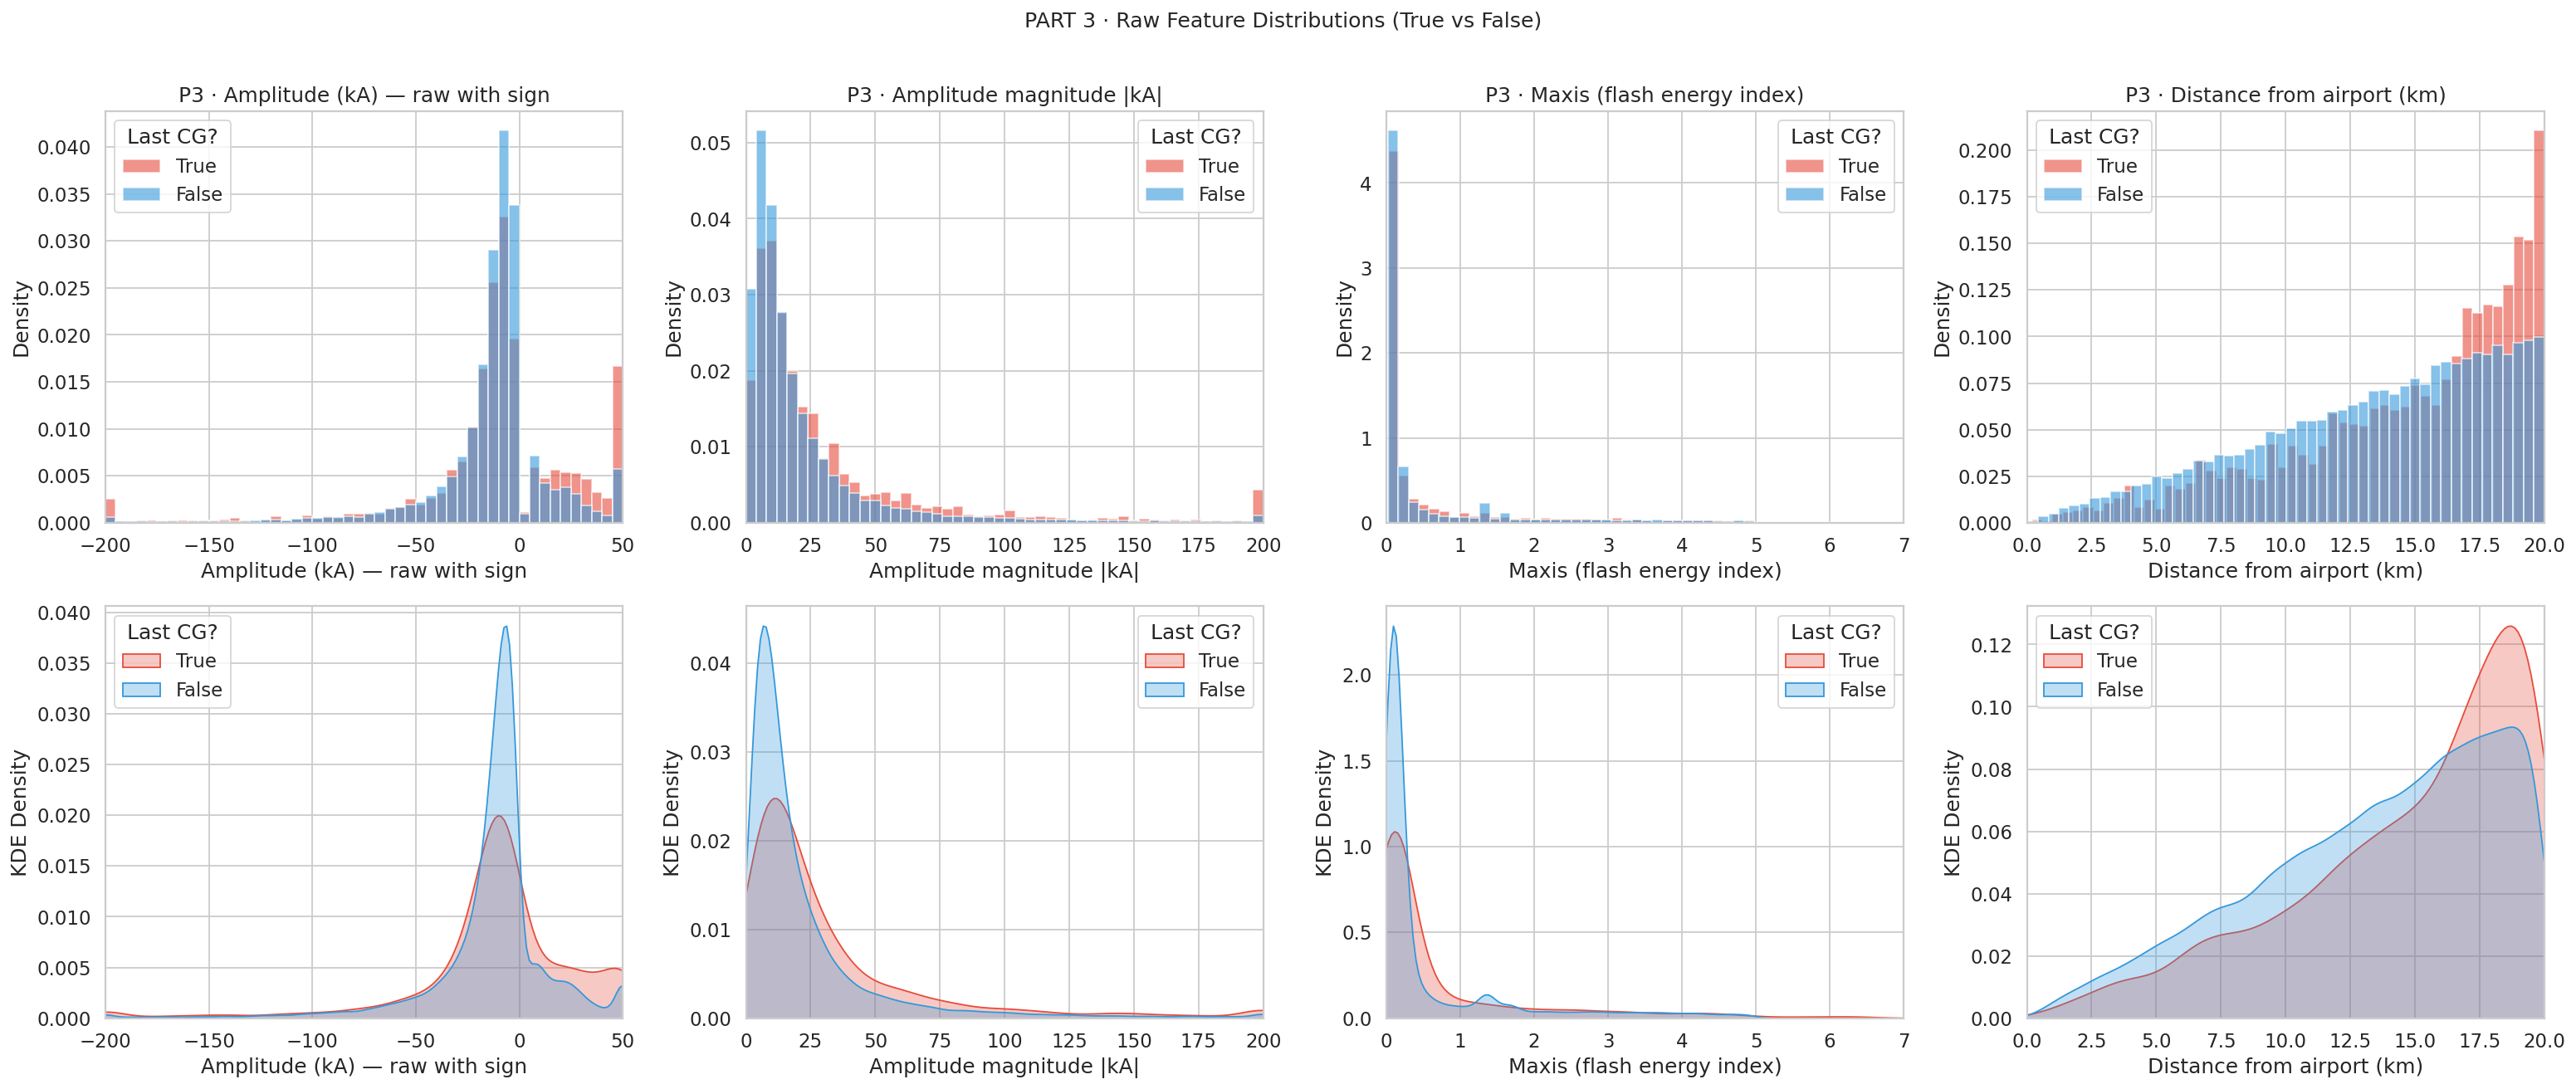

In [10]:
df_cg["amp_magnitude"] = df_cg["amplitude"].abs()

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

features_to_plot = [
    ("amplitude",     "Amplitude (kA) — raw with sign",    (-200, 50)),
    ("amp_magnitude", "Amplitude magnitude |kA|",           (0, 200)),
    ("maxis",         "Maxis (flash energy index)",         (0, 7)),
    ("dist",          "Distance from airport (km)",         (0, 20)),
]

for i, (feat, label, xlim) in enumerate(features_to_plot):
    ax_top = axes[0, i]
    ax_bot = axes[1, i]

    for lbl, color in PALETTE.items():
        subset = df_cg[df_cg["is_last_lightning_cloud_ground"]==lbl][feat].dropna()
        ax_top.hist(subset.clip(*xlim), bins=50, alpha=0.6,
                    color=color, label=lbl, density=True)
        try:
            sns.kdeplot(subset.clip(*xlim), ax=ax_bot,
                        color=color, label=lbl, fill=True, alpha=0.3)
        except Exception:
            pass

    ax_top.set_title(f"P3 · {label}")
    ax_top.set_xlabel(label)
    ax_top.set_ylabel("Density")
    ax_top.legend(title="Last CG?")
    ax_top.set_xlim(xlim)

    ax_bot.set_xlabel(label)
    ax_bot.set_ylabel("KDE Density")
    ax_bot.legend(title="Last CG?")
    ax_bot.set_xlim(xlim)

plt.suptitle("PART 3 · Raw Feature Distributions (True vs False)",
             fontsize=14, y=1.01)
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p3_raw_feature_distributions.png")
plt.show()

In [11]:
print("\n=== AMPLITUDE SIGN ANALYSIS ===")
for lbl in [True, False]:
    sub = df_cg[df_cg["is_last_lightning_cloud_ground"]==lbl]
    pos_pct = (sub["amplitude"] > 0).mean() * 100
    neg_pct = (sub["amplitude"] < 0).mean() * 100
    print(f"\n{lbl} strikes:")
    print(f"  Positive amplitude (+kA): {pos_pct:.1f}%")
    print(f"  Negative amplitude (-kA): {neg_pct:.1f}%")
    print(f"  Mean amplitude: {sub['amplitude'].mean():.2f} kA")
    print(f"  Mean |amplitude|: {sub['amplitude'].abs().mean():.2f} kA")


=== AMPLITUDE SIGN ANALYSIS ===

True strikes:
  Positive amplitude (+kA): 27.4%
  Negative amplitude (-kA): 72.3%
  Mean amplitude: -8.28 kA
  Mean |amplitude|: 32.38 kA

False strikes:
  Positive amplitude (+kA): 16.2%
  Negative amplitude (-kA): 83.8%
  Mean amplitude: -12.04 kA
  Mean |amplitude|: 22.32 kA


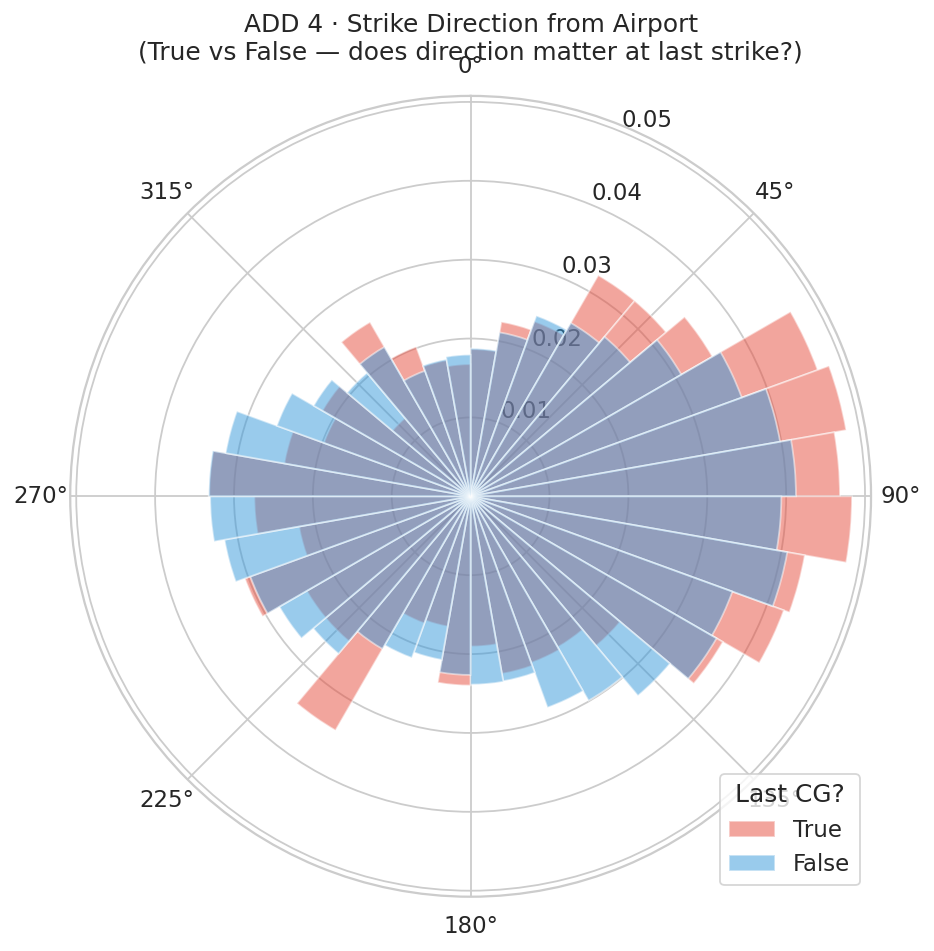

In [12]:
fig = plt.figure(figsize=(8, 8))
ax_polar = fig.add_subplot(111, projection="polar")

for lbl, color in PALETTE.items():
    sub = df_cg[df_cg["is_last_lightning_cloud_ground"]==lbl]["azimuth"]
    counts, bins = np.histogram(sub, bins=36, range=(0, 360))
    bin_centers  = np.radians((bins[:-1] + bins[1:]) / 2)
    ax_polar.bar(bin_centers, counts / counts.sum(),
                 width=np.radians(10), alpha=0.5,
                 color=color, label=lbl)

ax_polar.set_theta_zero_location("N")  # 0° = North
ax_polar.set_theta_direction(-1)       # clockwise like compass
ax_polar.set_title("ADD 4 · Strike Direction from Airport\n"
                   "(True vs False — does direction matter at last strike?)",
                   pad=20)
ax_polar.legend(loc="lower right", title="Last CG?")
save_to_drive(fig, FIG_DIR / "add4_azimuth_polar.png")
plt.show()

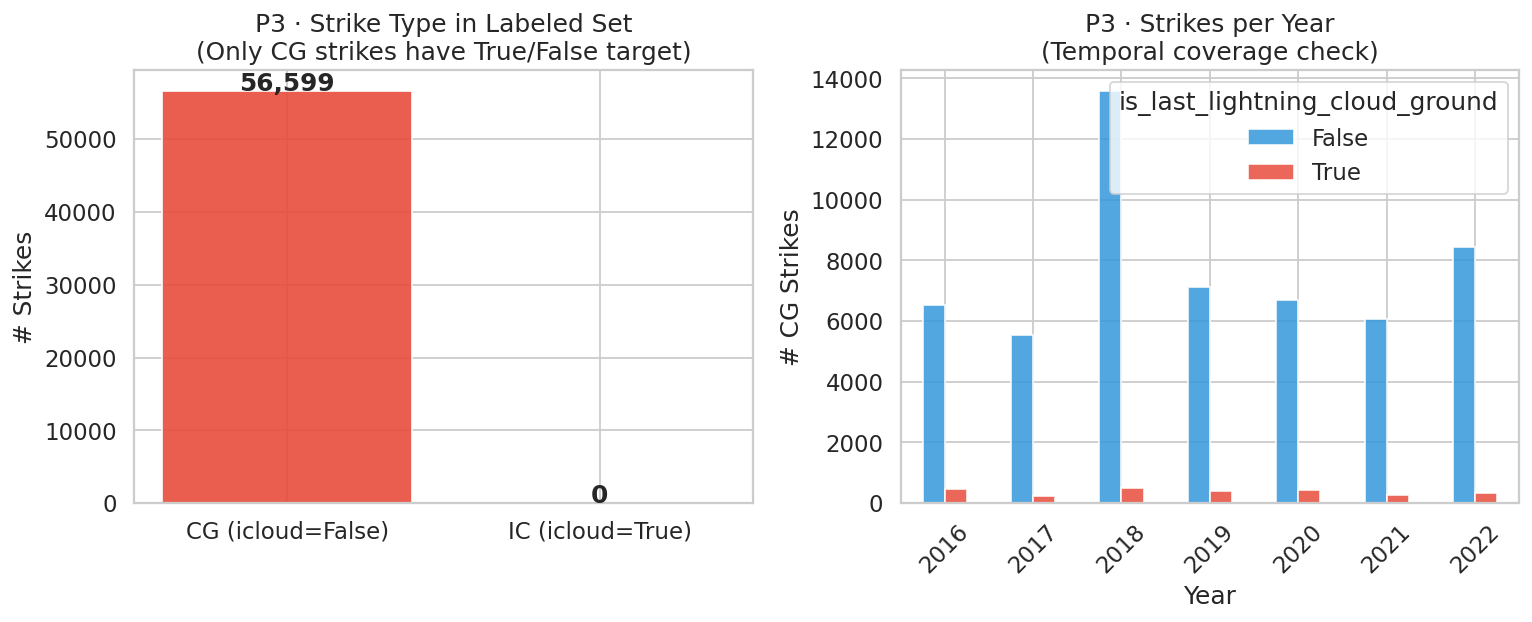

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# icloud — should be all False in labeled set
icloud_dist = df_inside["icloud"].value_counts()
axes[0].bar(["CG (icloud=False)", "IC (icloud=True)"],
            [icloud_dist.get(False, 0), icloud_dist.get(True, 0)],
            color=["#E74C3C", "#F39C12"], edgecolor="white", alpha=0.9)
axes[0].set_title("P3 · Strike Type in Labeled Set\n(Only CG strikes have True/False target)")
axes[0].set_ylabel("# Strikes")
for i, v in enumerate([icloud_dist.get(False,0), icloud_dist.get(True,0)]):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

# Year distribution (temporal coverage)
year_dist = df_cg.groupby(["year","is_last_lightning_cloud_ground"]).size().unstack(fill_value=0)
year_dist.plot(kind="bar", ax=axes[1],
               color=[PALETTE[False], PALETTE[True]],
               edgecolor="white", alpha=0.85)
axes[1].set_title("P3 · Strikes per Year\n(Temporal coverage check)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("# CG Strikes")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p3_feature_context.png")
plt.show()

---
## PART 4 — Storm Lifecycle EDA
What does a storm look like from start to True (last CG)?

In [14]:
df_cg = df_cg.sort_values(["segment_key", "date"])
grp   = df_cg.groupby("segment_key")

df_cg["rank_in_seg"]      = grp.cumcount()
df_cg["seg_size_cg"]      = grp["lightning_id"].transform("count")
df_cg["pct_position"]     = df_cg["rank_in_seg"] / df_cg["seg_size_cg"]
df_cg["time_since_prev"]  = grp["date"].diff().dt.total_seconds()
df_cg["dist_delta"]       = grp["dist"].diff()
df_cg["amp_delta"]        = grp["amplitude"].diff()
df_cg["rank_rev_cg"]      = (
    grp["date"].rank(method="first", ascending=False) - 1
)

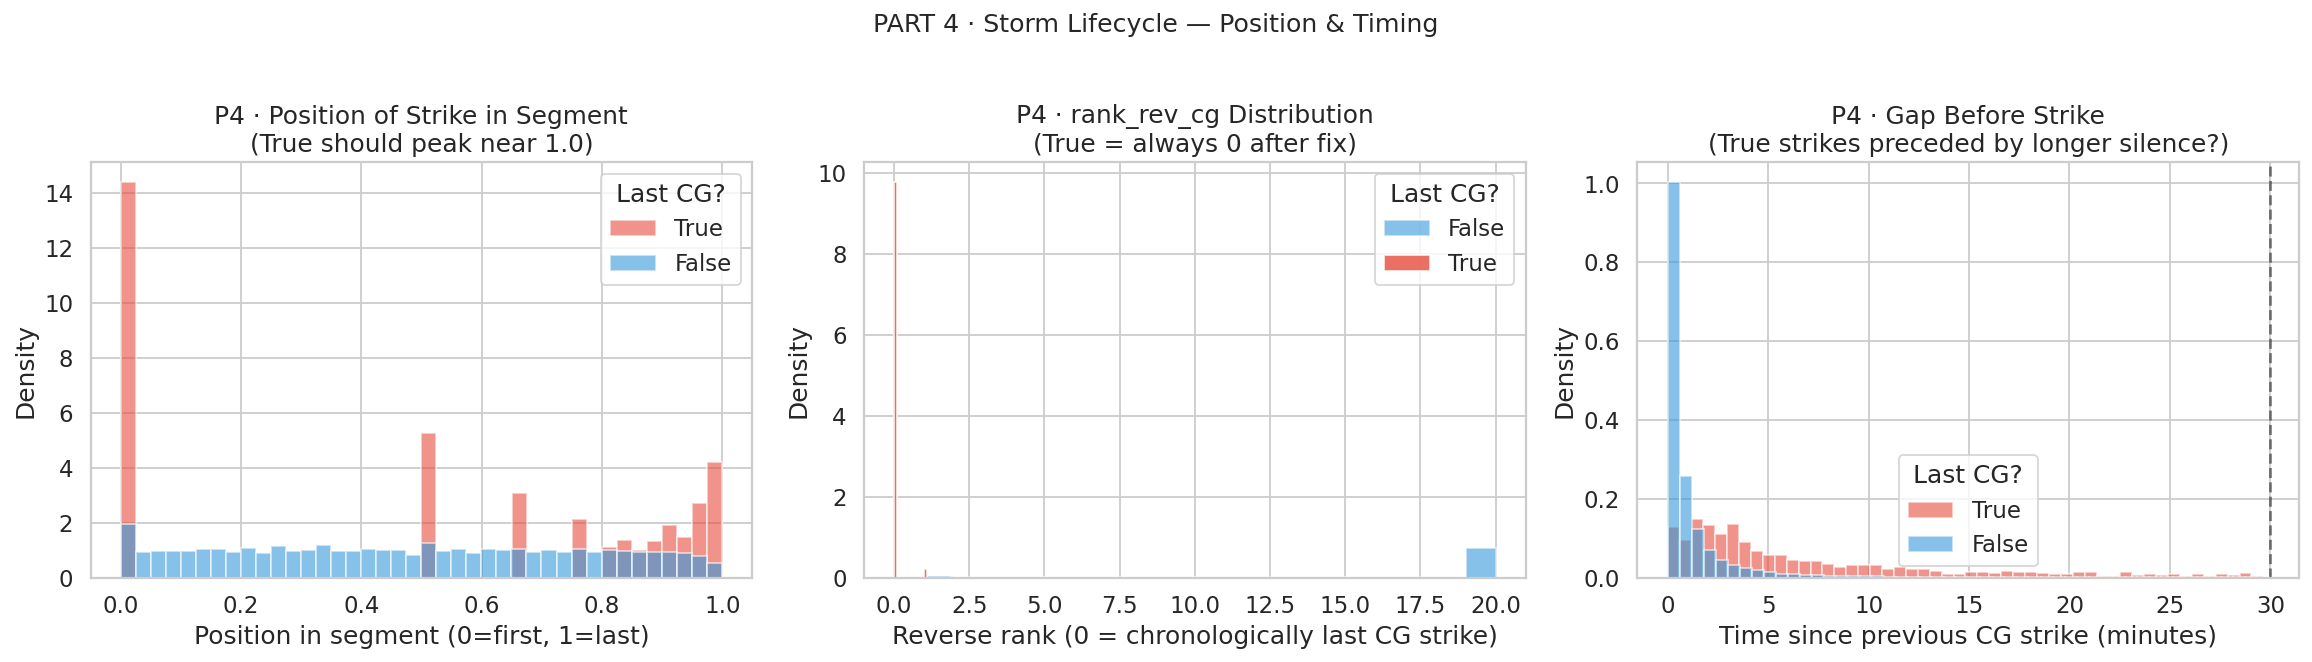

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# pct_position — True always near 1.0?
for lbl, color in PALETTE.items():
    sub = df_cg[df_cg["is_last_lightning_cloud_ground"]==lbl]["pct_position"]
    axes[0].hist(sub, bins=40, alpha=0.6, color=color,
                 label=lbl, density=True)
axes[0].set_xlabel("Position in segment (0=first, 1=last)")
axes[0].set_ylabel("Density")
axes[0].set_title("P4 · Position of Strike in Segment\n(True should peak near 1.0)")
axes[0].legend(title="Last CG?")

# rank_rev_cg — True should be 0
rank_rev_true  = df_cg[df_cg["is_last_lightning_cloud_ground"]]["rank_rev_cg"]
rank_rev_false = df_cg[~df_cg["is_last_lightning_cloud_ground"]]["rank_rev_cg"]
axes[1].hist(rank_rev_false.clip(0,20), bins=20, alpha=0.6,
             color=PALETTE[False], label="False", density=True)
axes[1].hist(rank_rev_true.clip(0,20),  bins=20, alpha=0.8,
             color=PALETTE[True],  label="True",  density=True)
axes[1].set_xlabel("Reverse rank (0 = chronologically last CG strike)")
axes[1].set_ylabel("Density")
axes[1].set_title("P4 · rank_rev_cg Distribution\n(True = always 0 after fix)")
axes[1].legend(title="Last CG?")

# time_since_prev — is silence growing before True?
for lbl, color in PALETTE.items():
    sub = df_cg[
        df_cg["is_last_lightning_cloud_ground"]==lbl
    ]["time_since_prev"].dropna().clip(0, 1800)
    axes[2].hist(sub/60, bins=50, alpha=0.6, color=color,
                 label=lbl, density=True)
axes[2].set_xlabel("Time since previous CG strike (minutes)")
axes[2].set_ylabel("Density")
axes[2].set_title("P4 · Gap Before Strike\n(True strikes preceded by longer silence?)")
axes[2].legend(title="Last CG?")
axes[2].axvline(30, color="black", linestyle="--", alpha=0.5,
                label="30 min threshold")

plt.suptitle("PART 4 · Storm Lifecycle — Position & Timing",
             fontsize=14, y=1.02)
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p4_storm_lifecycle_timing.png")
plt.show()

Biarritz segment keys in df_cg: ['Biarritz_1.0', 'Biarritz_10.0', 'Biarritz_100.0', 'Biarritz_101.0', 'Biarritz_102.0', 'Biarritz_103.0', 'Biarritz_104.0', 'Biarritz_105.0', 'Biarritz_106.0', 'Biarritz_107.0', 'Biarritz_108.0', 'Biarritz_109.0', 'Biarritz_11.0', 'Biarritz_110.0', 'Biarritz_111.0', 'Biarritz_112.0', 'Biarritz_113.0', 'Biarritz_114.0', 'Biarritz_115.0', 'Biarritz_116.0', 'Biarritz_117.0', 'Biarritz_118.0', 'Biarritz_119.0', 'Biarritz_12.0', 'Biarritz_120.0', 'Biarritz_121.0', 'Biarritz_122.0', 'Biarritz_123.0', 'Biarritz_124.0', 'Biarritz_125.0', 'Biarritz_126.0', 'Biarritz_127.0', 'Biarritz_128.0', 'Biarritz_129.0', 'Biarritz_13.0', 'Biarritz_130.0', 'Biarritz_131.0', 'Biarritz_132.0', 'Biarritz_133.0', 'Biarritz_134.0', 'Biarritz_135.0', 'Biarritz_136.0', 'Biarritz_137.0', 'Biarritz_138.0', 'Biarritz_139.0', 'Biarritz_14.0', 'Biarritz_140.0', 'Biarritz_141.0', 'Biarritz_142.0', 'Biarritz_143.0', 'Biarritz_144.0', 'Biarritz_145.0', 'Biarritz_146.0', 'Biarritz_147.0', 'B

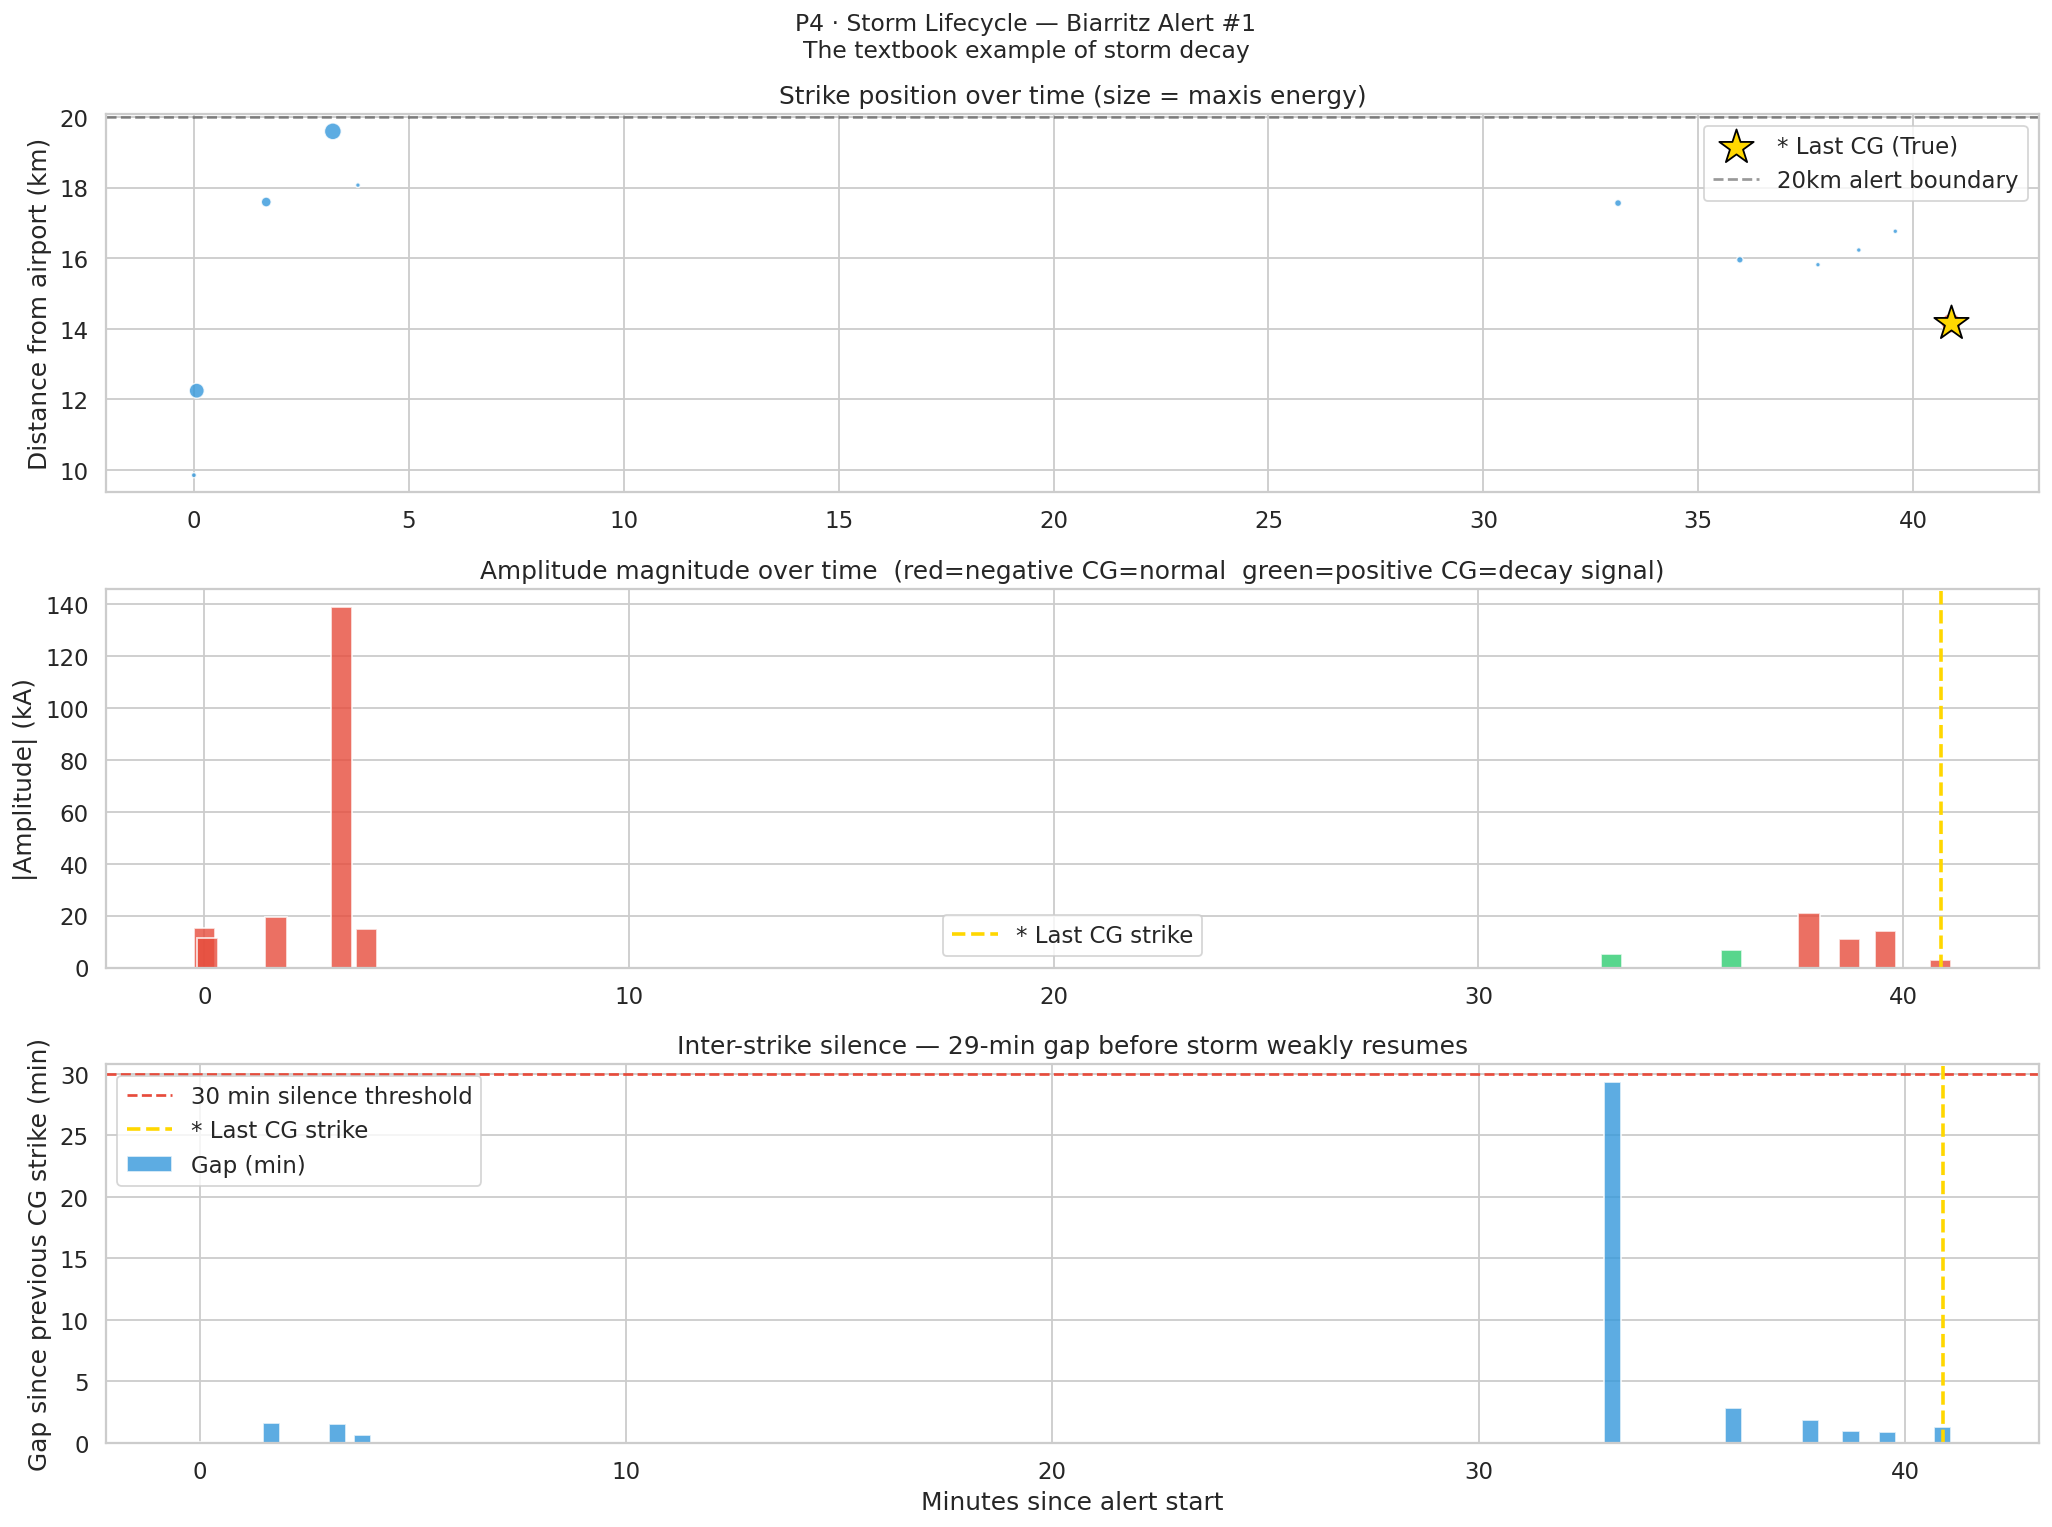

In [16]:
# Debug: find the actual Biarritz segment keys available in df_cg
_biarritz_keys = sorted(df_cg[df_cg["airport"]=="Biarritz"]["segment_key"].unique())
print(f"Biarritz segment keys in df_cg: {_biarritz_keys}")
_biarritz_key = _biarritz_keys[0] if _biarritz_keys else "Biarritz_1.0"
print(f"Using key: {_biarritz_key}")
biarritz_1 = df_cg[df_cg["segment_key"]==_biarritz_key].sort_values("date").copy()
print(f"Biarritz_1 rows: {len(biarritz_1)}, True rows: {biarritz_1['is_last_lightning_cloud_ground'].sum()}")
biarritz_1["minutes"] = (
    biarritz_1["date"] - biarritz_1["date"].min()
).dt.total_seconds() / 60
biarritz_1["gap_min"] = biarritz_1["date"].diff().dt.total_seconds() / 60

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("P4 · Storm Lifecycle — Biarritz Alert #1\n"
             "The textbook example of storm decay", fontsize=13)

# Strike timeline: dist over time
colors = ["#E74C3C" if t else "#3498DB"
          for t in biarritz_1["is_last_lightning_cloud_ground"]]
sizes  = (biarritz_1["maxis"].abs() + 0.1) * 40
axes[0].scatter(biarritz_1["minutes"], biarritz_1["dist"],
                c=colors, s=sizes, alpha=0.8,
                edgecolors="white", lw=0.8, zorder=3)
true_row = biarritz_1[biarritz_1["is_last_lightning_cloud_ground"]]
axes[0].scatter(true_row["minutes"], true_row["dist"],
                s=400, marker="*", color="gold",
                edgecolors="black", lw=1, zorder=5,
                label="* Last CG (True)")
axes[0].axhline(20, color="black", linestyle="--",
                alpha=0.4, label="20km alert boundary")
axes[0].set_ylabel("Distance from airport (km)")
axes[0].set_title("Strike position over time (size = maxis energy)")
axes[0].legend()

# Amplitude over time with sign highlighted
for _, row in biarritz_1.iterrows():
    color = "#E74C3C" if row["amplitude"] < 0 else "#2ECC71"
    axes[1].bar(row["minutes"], abs(row["amplitude"]),
                width=0.5, color=color, alpha=0.8)
if len(true_row) > 0:
    axes[1].axvline(true_row["minutes"].values[0],
                    color="gold", linewidth=2, linestyle="--",
                    label="* Last CG strike")
axes[1].set_ylabel("|Amplitude| (kA)")
axes[1].set_title("Amplitude magnitude over time  "
                  "(red=negative CG=normal  green=positive CG=decay signal)")
axes[1].legend()

# Inter-strike gap over time
gap_data = biarritz_1.iloc[1:]
axes[2].bar(gap_data["minutes"], gap_data["gap_min"],
            width=0.4, color="#3498DB", alpha=0.8, label="Gap (min)")
axes[2].axhline(30, color="#E74C3C", linestyle="--",
                linewidth=1.5, label="30 min silence threshold")
if len(true_row) > 0:
    axes[2].axvline(true_row["minutes"].values[0],
                    color="gold", linewidth=2, linestyle="--",
                    label="* Last CG strike")
axes[2].set_xlabel("Minutes since alert start")
axes[2].set_ylabel("Gap since previous CG strike (min)")
axes[2].set_title("Inter-strike silence — 29-min gap before storm weakly resumes")
axes[2].legend()

plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p4_biarritz_storm_lifecycle.png")
plt.show()

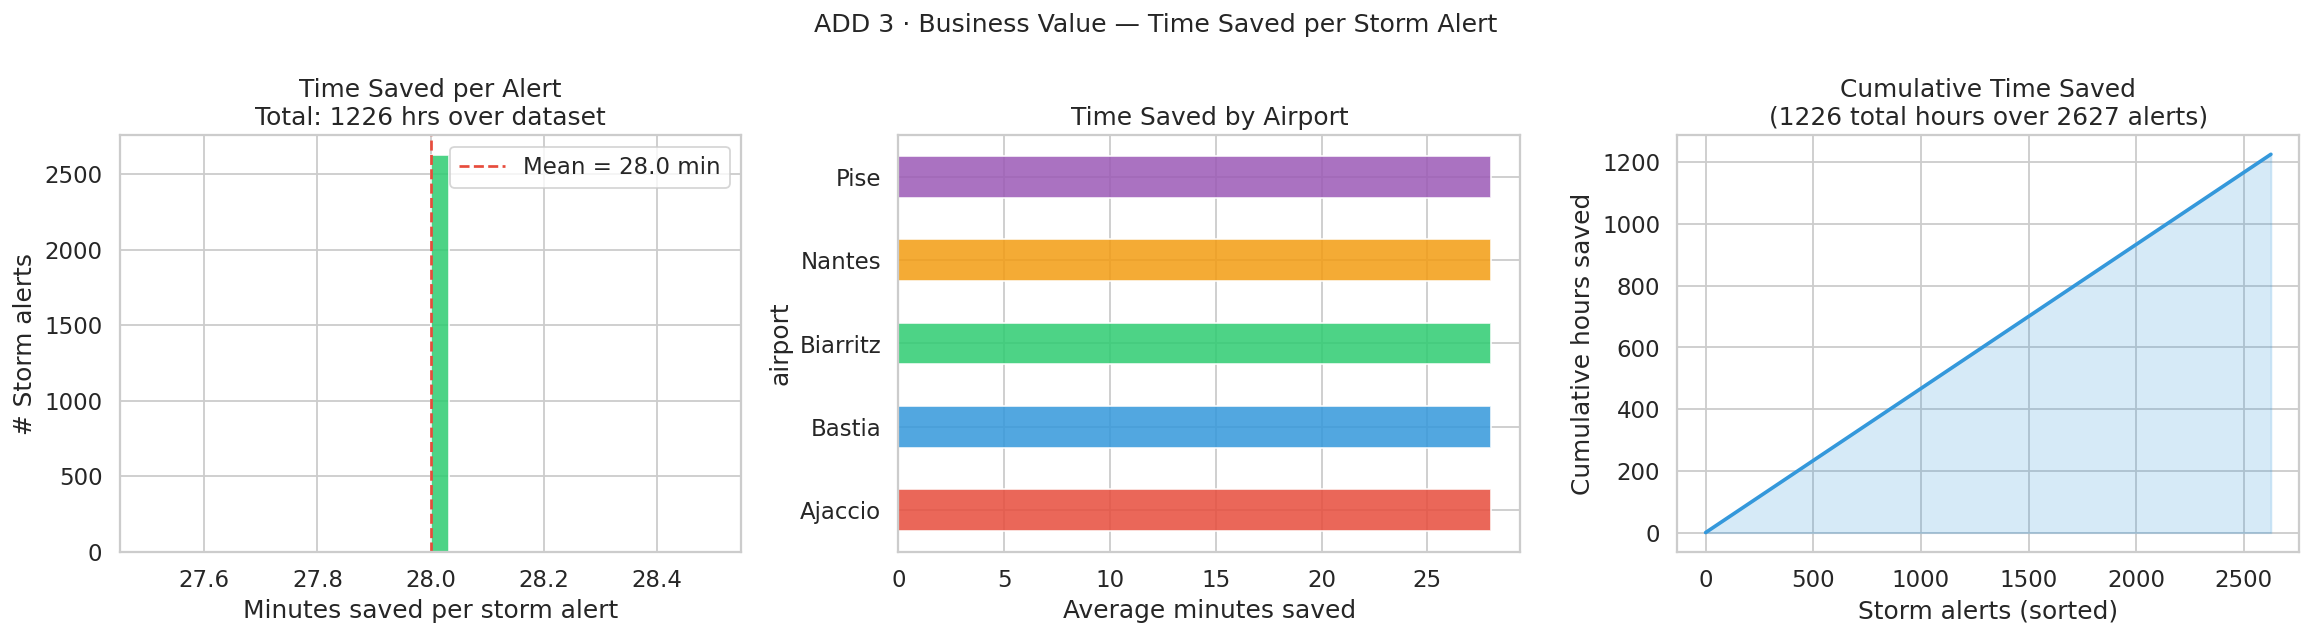

In [17]:
# For each segment: when does model first predict P > threshold vs
# when does the 30-min rule confirm the end?

savings = []
for seg_id, seg in df_cg.groupby("segment_key"):
    seg = seg.sort_values("date")
    last_strike_time = seg["date"].max()
    rule_end_time    = last_strike_time + pd.Timedelta("30min")

    # With model: airport can prepare from the moment last strike is detected
    # Assume model needs 2 minutes to confirm (safety buffer)
    model_end_time   = last_strike_time + pd.Timedelta("2min")

    time_saved_min   = (rule_end_time - model_end_time).total_seconds() / 60
    savings.append({
        "segment_key"   : seg_id,
        "airport"       : seg["airport"].iloc[0],
        "time_saved_min": time_saved_min,
        "duration_min"  : (last_strike_time - seg["date"].min())
                          .total_seconds() / 60,
    })

savings_df = pd.DataFrame(savings)
total_hours_saved = savings_df["time_saved_min"].sum() / 60

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ADD 3 · Business Value — Time Saved per Storm Alert",
             fontsize=14)

# Distribution of time saved
axes[0].hist(savings_df["time_saved_min"], bins=30,
             color="#2ECC71", edgecolor="white", alpha=0.85)
axes[0].axvline(savings_df["time_saved_min"].mean(),
                color="#E74C3C", linestyle="--",
                label=f"Mean = {savings_df['time_saved_min'].mean():.1f} min")
axes[0].set_xlabel("Minutes saved per storm alert")
axes[0].set_ylabel("# Storm alerts")
axes[0].set_title(f"Time Saved per Alert\n"
                  f"Total: {total_hours_saved:.0f} hrs over dataset")
axes[0].legend()

# Per airport
savings_df.groupby("airport")["time_saved_min"].mean().sort_values()\
    .plot(kind="barh", ax=axes[1],
          color=[AP_COLORS.get(a, "gray")
                 for a in savings_df.groupby("airport")["time_saved_min"]
                 .mean().sort_values().index],
          edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Average minutes saved")
axes[1].set_title("Time Saved by Airport")

# Cumulative time saved
savings_df_sorted = savings_df.sort_values("time_saved_min")
axes[2].plot(range(len(savings_df_sorted)),
             savings_df_sorted["time_saved_min"].cumsum() / 60,
             color="#3498DB", linewidth=2)
axes[2].set_xlabel("Storm alerts (sorted)")
axes[2].set_ylabel("Cumulative hours saved")
axes[2].set_title(f"Cumulative Time Saved\n"
                  f"({total_hours_saved:.0f} total hours over {len(savings_df)} alerts)")
axes[2].fill_between(range(len(savings_df_sorted)),
                     savings_df_sorted["time_saved_min"].cumsum() / 60,
                     alpha=0.2, color="#3498DB")

plt.tight_layout()
save_to_drive(fig, FIG_DIR / "add3_business_value.png")
plt.show()

save_to_drive(savings_df, SAVES_DIR / "time_savings_per_storm.csv")

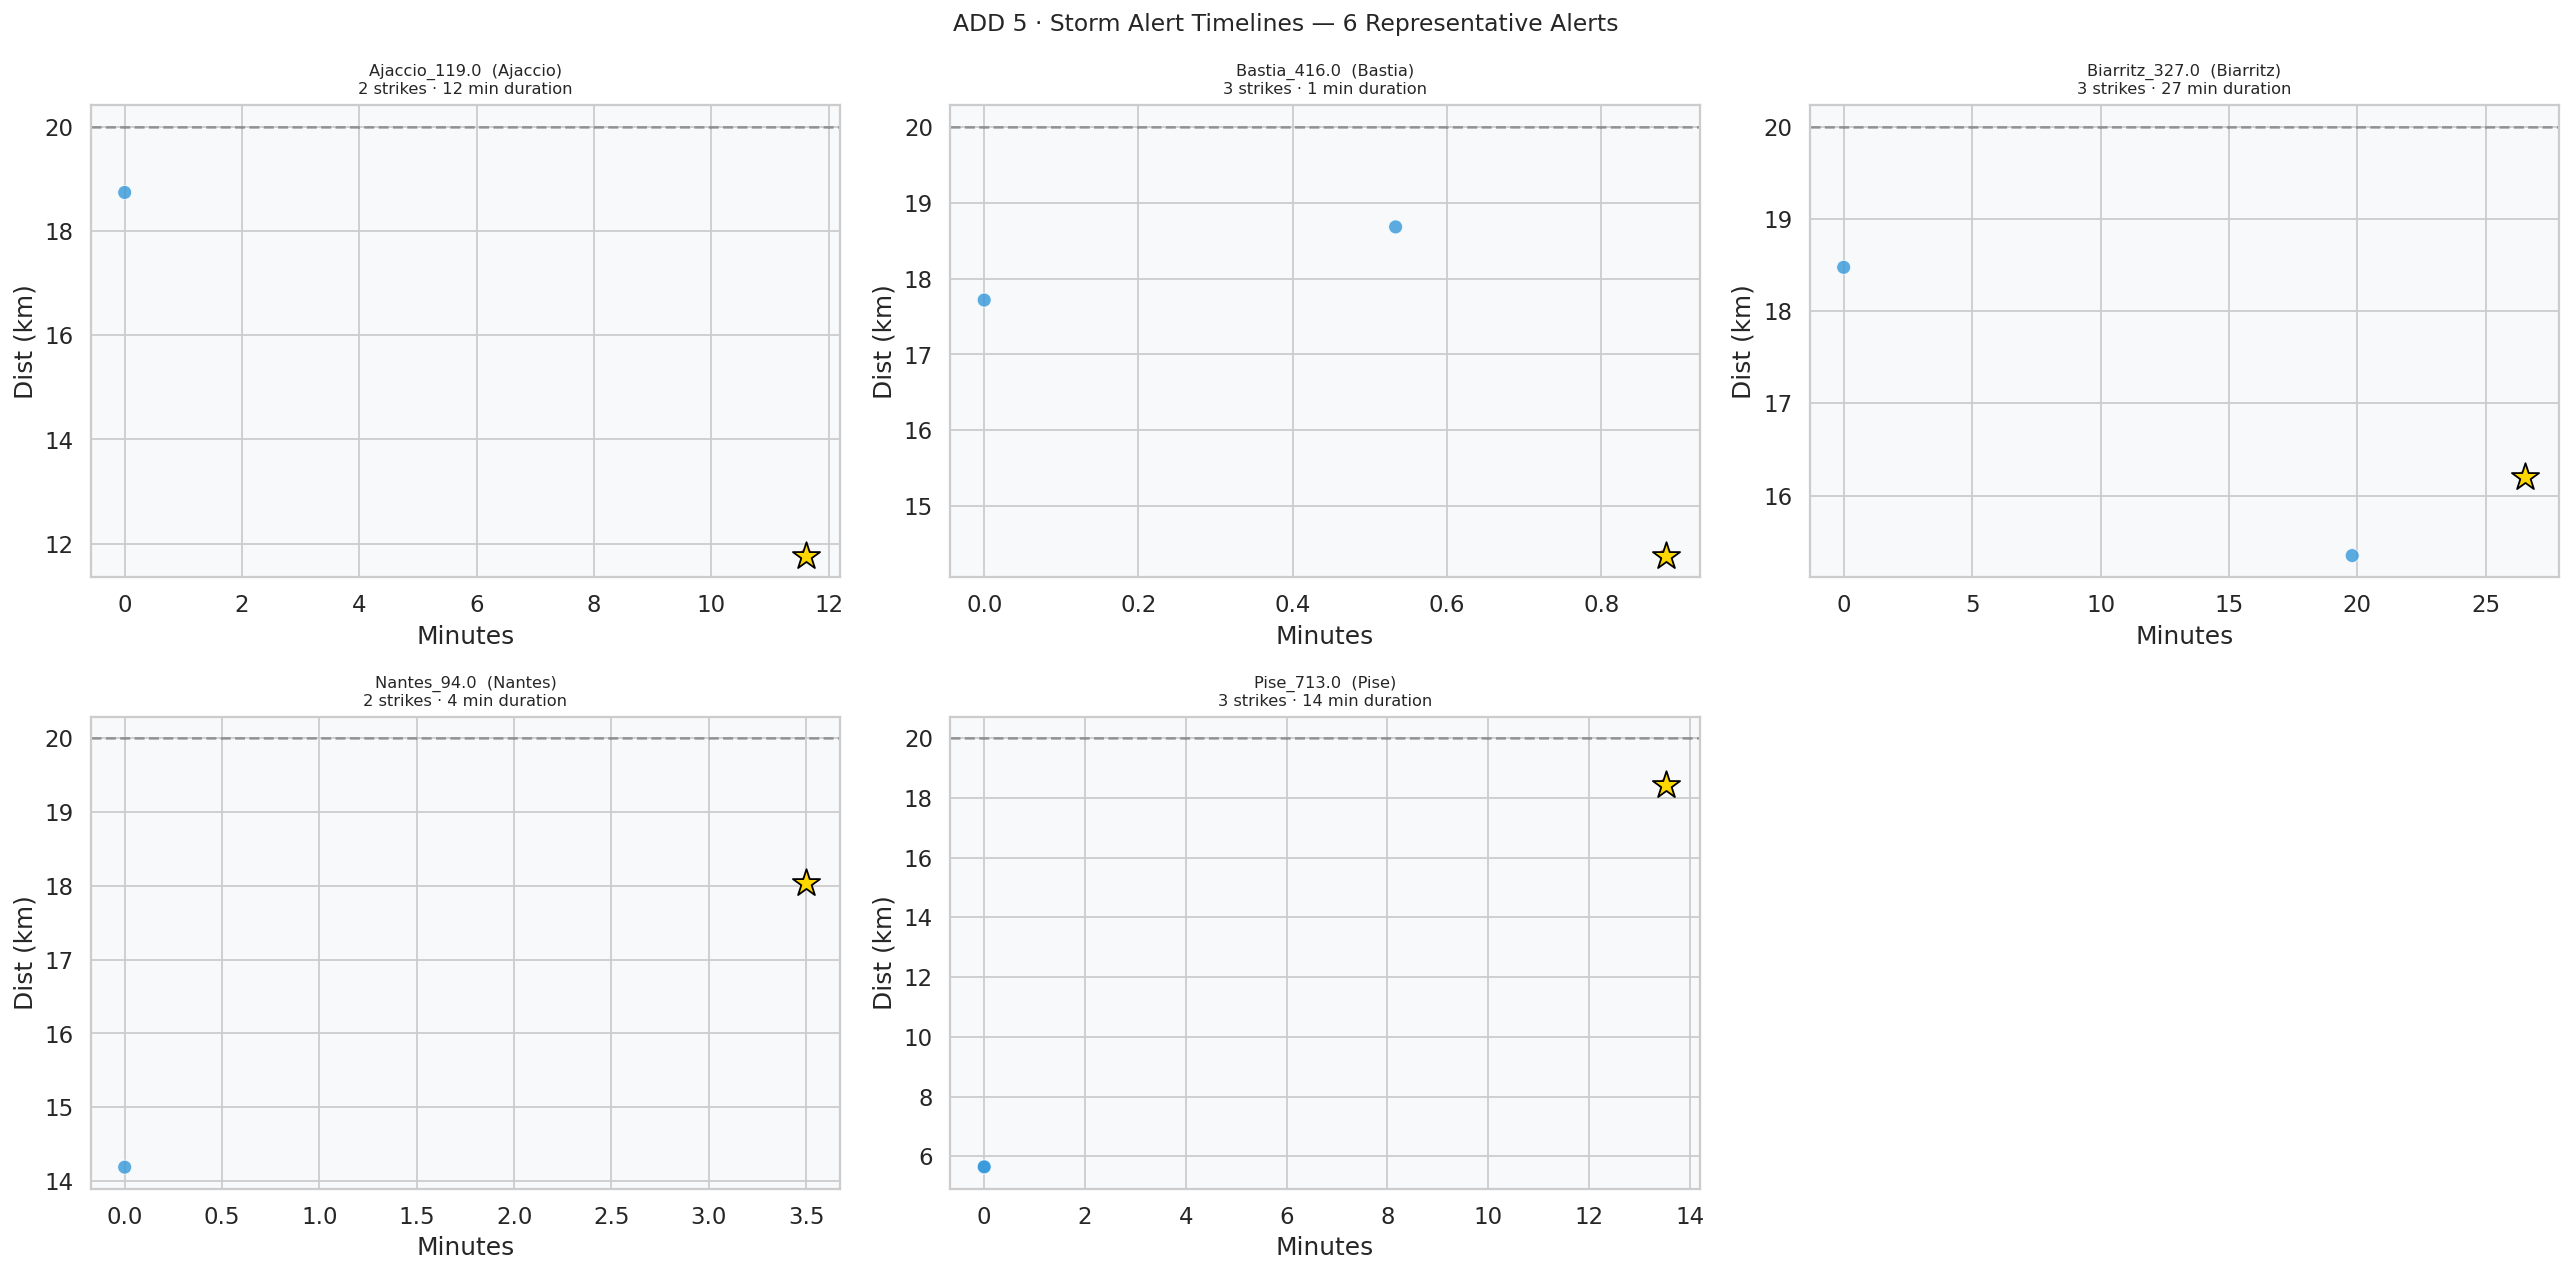

In [18]:
# Pick 6 diverse segments: short, long, single-strike, multi-airport
sample_segs = (
    seg_stats.sort_values("n_strikes")
    .groupby("airport", group_keys=False)
    .apply(lambda x: x.iloc[[len(x) // 2]])
    .reset_index(drop=True)["segment_key"].tolist()
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("ADD 5 · Storm Alert Timelines — 6 Representative Alerts",
             fontsize=13)

for ax, seg_id in zip(axes.flatten(), sample_segs):
    seg = df_cg[df_cg["segment_key"] == seg_id].sort_values("date").copy()
    seg["minutes"] = (
        seg["date"] - seg["date"].min()
    ).dt.total_seconds() / 60

    colors_s = ["#E74C3C" if t else "#3498DB"
                for t in seg["is_last_lightning_cloud_ground"]]
    ax.scatter(seg["minutes"], seg["dist"],
               c=colors_s, s=60, alpha=0.8,
               edgecolors="white", lw=0.5)

    true_row = seg[seg["is_last_lightning_cloud_ground"]]
    if len(true_row):
        ax.scatter(true_row["minutes"], true_row["dist"],
                   s=250, marker="*", color="gold",
                   edgecolors="black", lw=1, zorder=5)

    ax.axhline(20, color="black", linestyle="--", alpha=0.3)
    ax.set_xlabel("Minutes")
    ax.set_ylabel("Dist (km)")
    airport = seg["airport"].iloc[0]
    ax.set_title(
        f"{seg_id}  ({airport})\n"
        f"{len(seg)} strikes · "
        f"{seg['minutes'].max():.0f} min duration",
        fontsize=9
    )
    ax.set_facecolor("#F8F9FA")

# Hide unused axes if fewer than 6 segments
for ax in axes.flatten()[len(sample_segs):]:
    ax.set_visible(False)

plt.tight_layout()
save_to_drive(fig, FIG_DIR / "add5_storm_gallery.png")
plt.show()

---
## PART 5 — Airport Profiles

In [19]:
ap_seg_stats = seg_stats.groupby("airport").agg(
    n_segments       = ("segment_key", "count"),
    median_strikes   = ("n_strikes", "median"),
    mean_strikes     = ("n_strikes", "mean"),
    median_duration  = ("duration_min", "median"),
    max_duration     = ("duration_min", "max"),
).round(1)

print("\n=== AIRPORT PROFILES ===")
print(ap_seg_stats.to_string())


=== AIRPORT PROFILES ===
          n_segments  median_strikes  mean_strikes  median_duration  max_duration
airport                                                                          
Ajaccio          530             2.0          20.1              8.4         400.1
Bastia           532             3.0          25.8             10.1         497.8
Biarritz         590             3.0          16.8              7.1         387.6
Nantes           206             2.0          21.3              8.8         381.5
Pise             769             3.0          23.3             11.3         578.7


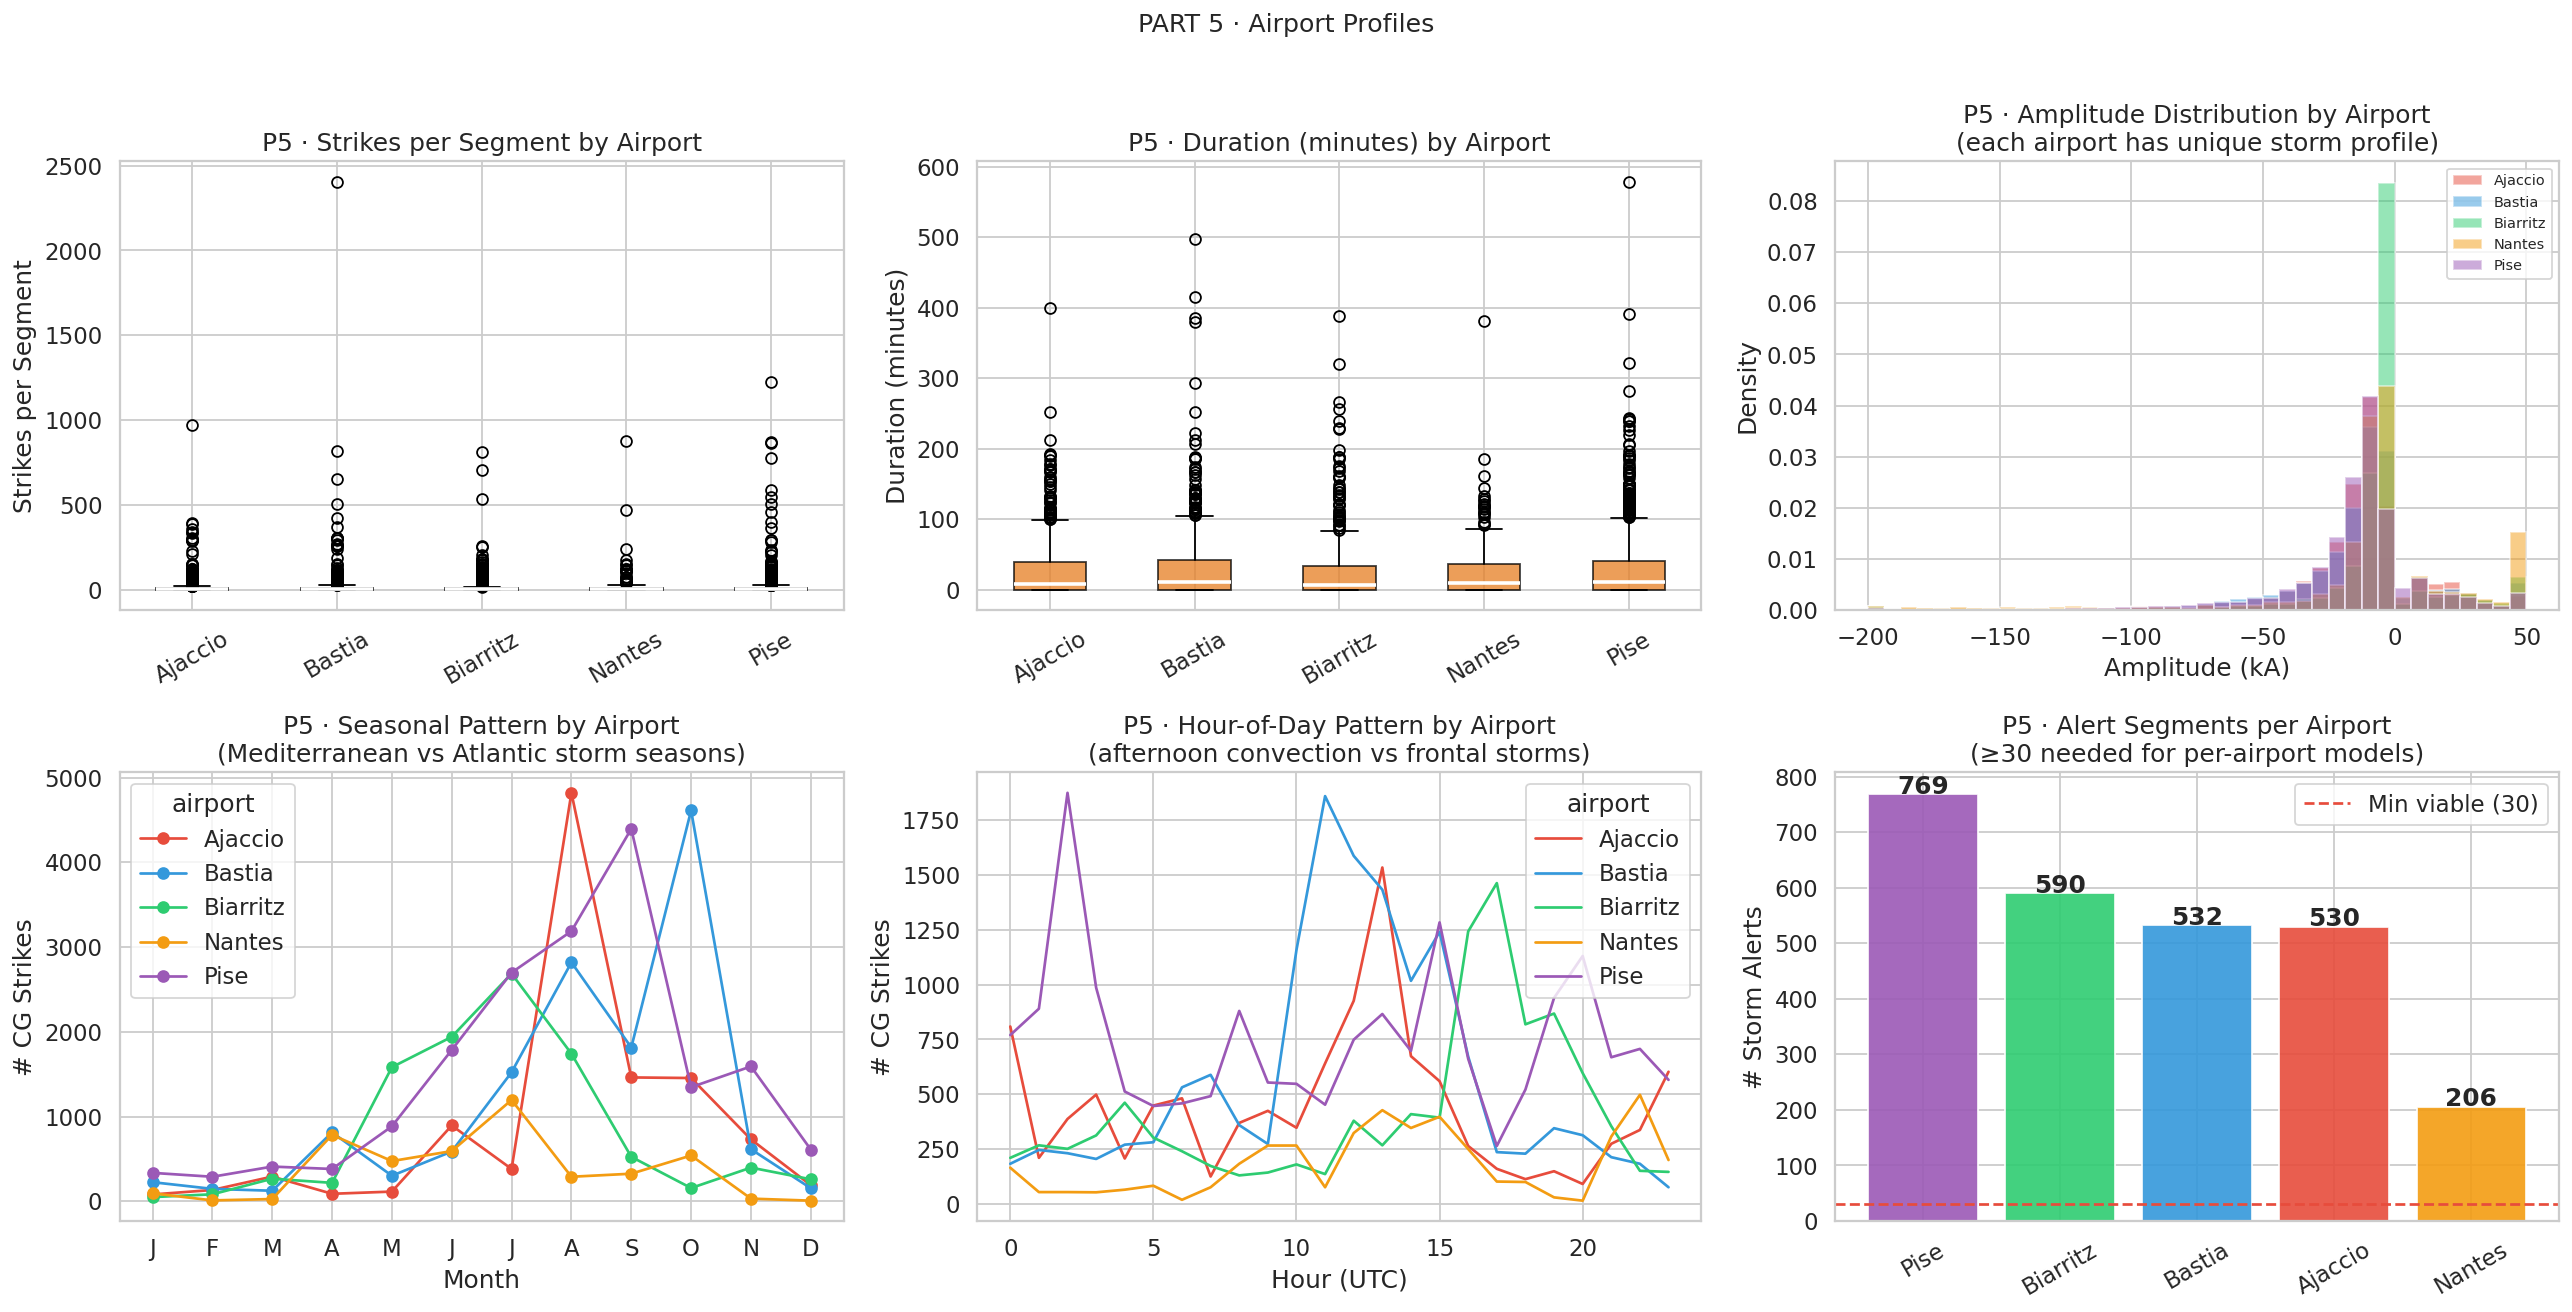

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
airports = sorted(df_cg["airport"].dropna().unique())

metrics = [
    ("n_strikes",   "Strikes per Segment",        "#2980B9"),
    ("duration_min","Duration (minutes)",          "#E67E22"),
]

for ax, (metric, label, color) in zip(axes[0,:2], metrics):
    data = [seg_stats[seg_stats["airport"]==ap][metric].dropna().values
            for ap in airports]
    bp = ax.boxplot(data, labels=airports, patch_artist=True,
                    medianprops={"color":"white","linewidth":2})
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f"P5 · {label} by Airport")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=30)

# Per-airport amplitude distribution
for ap in airports:
    sub = df_cg[df_cg["airport"]==ap]["amplitude"].clip(-200,50)
    axes[0,2].hist(sub, bins=40, alpha=0.5,
                   color=AP_COLORS.get(ap,"gray"),
                   label=ap, density=True)
axes[0,2].set_xlabel("Amplitude (kA)")
axes[0,2].set_ylabel("Density")
axes[0,2].set_title("P5 · Amplitude Distribution by Airport\n"
                    "(each airport has unique storm profile)")
axes[0,2].legend(fontsize=8)

# Per-airport seasonal pattern
month_airport = df_cg.groupby(["airport","month"]).size().unstack(fill_value=0)
month_airport.T.plot(ax=axes[1,0],
                     color=[AP_COLORS.get(a,"gray") for a in month_airport.index],
                     marker="o")
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("# CG Strikes")
axes[1,0].set_title("P5 · Seasonal Pattern by Airport\n"
                    "(Mediterranean vs Atlantic storm seasons)")
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

# Per-airport hour pattern
hour_airport = df_cg.groupby(["airport","hour"]).size().unstack(fill_value=0)
hour_airport.T.plot(ax=axes[1,1],
                    color=[AP_COLORS.get(a,"gray") for a in hour_airport.index])
axes[1,1].set_xlabel("Hour (UTC)")
axes[1,1].set_ylabel("# CG Strikes")
axes[1,1].set_title("P5 · Hour-of-Day Pattern by Airport\n"
                    "(afternoon convection vs frontal storms)")

# Segments per airport
ap_counts = seg_stats.groupby("airport").size().sort_values(ascending=False)
bars = axes[1,2].bar(ap_counts.index, ap_counts.values,
                     color=[AP_COLORS.get(a,"gray") for a in ap_counts.index],
                     edgecolor="white", alpha=0.9)
for bar, val in zip(bars, ap_counts.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5, str(val),
                   ha="center", fontweight="bold")
axes[1,2].set_title("P5 · Alert Segments per Airport\n"
                    "(≥30 needed for per-airport models)")
axes[1,2].set_ylabel("# Storm Alerts")
axes[1,2].axhline(30, color="#E74C3C", linestyle="--",
                  label="Min viable (30)")
axes[1,2].legend()
axes[1,2].tick_params(axis="x", rotation=30)

plt.suptitle("PART 5 · Airport Profiles", fontsize=14, y=1.01)
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p5_airport_profiles.png")
plt.show()

---
## PART 6 — Feature Engineering
Every feature with physical motivation and code

In [21]:
log.info("Engineering all features ...")

df_cg = df_cg.sort_values(["segment_key", "date"])
grp   = df_cg.groupby("segment_key")

# ── GROUP A: Amplitude decomposition ────────────────────────────────────────
# Physical: sign encodes storm phase, magnitude encodes intensity
df_cg["amp_magnitude"]    = df_cg["amplitude"].abs()
df_cg["amp_is_positive"]  = (df_cg["amplitude"] > 0).astype(int)
# Positive CG strikes increase during storm decay — key decay signal

# ── GROUP B: Segment-level aggregations ─────────────────────────────────────
# Physical: how big and long is this storm overall
df_cg["seg_size_cg"]      = grp["lightning_id"].transform("count")
df_cg["seg_mean_amp"]     = grp["amplitude"].transform("mean")
df_cg["seg_std_amp"]      = grp["amplitude"].transform("std")
df_cg["seg_mean_mag"]     = grp["amp_magnitude"].transform("mean")
df_cg["seg_duration_min"] = grp["date"].transform(
    lambda x: (x.max()-x.min()).total_seconds()/60)
df_cg["seg_mean_dist"]    = grp["dist"].transform("mean")
df_cg["seg_pos_cg_ratio"] = grp["amp_is_positive"].transform("mean")
# Ratio of positive CG strikes in full segment — storm phase indicator

# ── GROUP C: Position within segment ────────────────────────────────────────
# Physical: where in the storm lifecycle is this strike?
df_cg["rank_in_seg"]      = grp.cumcount()
df_cg["pct_position"]     = df_cg["rank_in_seg"] / df_cg["seg_size_cg"]
df_cg["rank_rev_cg"]      = (
    grp["date"].rank(method="first", ascending=False) - 1
)
# rank_rev_cg=0 means this is the last CG strike (validated: 1 True per segment)

# ── GROUP D: Lag / delta features ────────────────────────────────────────────
# Physical: how is the storm changing moment to moment?
df_cg["time_since_prev"]  = grp["date"].diff().dt.total_seconds()
df_cg["dist_delta"]       = grp["dist"].diff()
# Positive dist_delta = storm moving away from airport = ending signal
df_cg["amp_delta"]        = grp["amplitude"].diff()
df_cg["mag_delta"]        = grp["amp_magnitude"].diff()
# Negative mag_delta = weakening storm = ending signal

# ── GROUP E: Rolling window features (last N minutes) ───────────────────────
# Physical: recent activity rate — is the storm slowing down?
df_cg_indexed = df_cg.set_index("date")
for window in ["5min", "10min", "15min", "30min"]:
    col = f"cg_count_{window}"
    df_cg[col] = (
        df_cg_indexed.groupby("segment_key")["amp_magnitude"]
        .rolling(window).count()
        .reset_index(level=0, drop=True)
        .values
    )

df_cg["rolling_mean_mag_10min"] = (
    df_cg_indexed.groupby("segment_key")["amp_magnitude"]
    .rolling("10min").mean()
    .reset_index(level=0, drop=True)
    .values
)
df_cg["rolling_pos_ratio_10min"] = (
    df_cg_indexed.groupby("segment_key")["amp_is_positive"]
    .rolling("10min").mean()
    .reset_index(level=0, drop=True)
    .values
)
df_cg["rolling_mean_dist_10min"] = (
    df_cg_indexed.groupby("segment_key")["dist"]
    .rolling("10min").mean()
    .reset_index(level=0, drop=True)
    .values
)

# ── GROUP F: Cartesian storm tracking ───────────────────────────────────────
# Physical: reconstruct storm movement vector from polar coords
df_cg["strike_x"] = df_cg["dist"] * np.sin(np.radians(df_cg["azimuth"]))
df_cg["strike_y"] = df_cg["dist"] * np.cos(np.radians(df_cg["azimuth"]))
df_cg["dx"]       = grp["strike_x"].diff()
df_cg["dy"]       = grp["strike_y"].diff()
df_cg["storm_speed"] = np.sqrt(df_cg["dx"]**2 + df_cg["dy"]**2)
# storm_speed = how fast storm is moving across the alert zone
# Fast-moving storm exits zone quickly → shorter alert

# ── GROUP G: Non-linear threshold features ──────────────────────────────────
# Physical: regime change indicators
df_cg["silence_over_10min"] = (
    df_cg["time_since_prev"] > 600).astype(int)
df_cg["silence_over_15min"] = (
    df_cg["time_since_prev"] > 900).astype(int)
df_cg["silence_over_20min"] = (
    df_cg["time_since_prev"] > 1200).astype(int)
# Any silence > 20 min means storm nearly ended → very strong True signal

# ── GROUP H: Interaction features ───────────────────────────────────────────
# Physical: combine complementary decay signals
df_cg["silence_x_dist_away"] = (
    df_cg["silence_over_15min"] * (df_cg["dist_delta"] > 0).astype(int)
)
# = 1 only when: long silence AND storm moving away → strongest end signal
df_cg["weak_and_moving_away"] = (
    (df_cg["amp_magnitude"] < df_cg["seg_mean_mag"]) &
    (df_cg["dist_delta"] > 0)
).astype(int)

# ── GROUP I: Calendar features ───────────────────────────────────────────────
# Physical: storm climatology varies by time
df_cg["hour"]      = df_cg["date"].dt.hour
df_cg["month"]     = df_cg["date"].dt.month
df_cg["dayofweek"] = df_cg["date"].dt.dayofweek
df_cg["is_summer"] = df_cg["month"].isin([6,7,8]).astype(int)
df_cg["is_afternoon"] = df_cg["hour"].isin(range(12,19)).astype(int)

# ── GROUP J: Airport encoding ────────────────────────────────────────────────
# For LightGBM native categorical — convert to category dtype
df_cg["airport_cat"] = df_cg["airport"].astype("category")

# Airport target encoding (compute on training fold only in CV)
# Here we compute globally for EDA only — recompute per fold in model
airport_pos_rate = df_cg.groupby("airport")["is_last_lightning_cloud_ground"]\
    .mean()
df_cg["airport_target_enc"] = df_cg["airport"].map(airport_pos_rate)

# ── GROUP K: Outside-zone context features (vectorised) ─────────────────────
# Physical: is the storm still being fed from the outer ring (20-50km)?
# This uses the 450K unlabeled rows as context for each inside-zone strike.
# Uses rolling + merge_asof for speed — avoids row-by-row loop on 500K rows.

df_outside_cg = df_outside[df_outside["icloud"] == False].copy()
df_outside_cg["date"] = pd.to_datetime(df_outside_cg["date"], utc=True)
df_outside_cg = df_outside_cg.sort_values(["airport", "date"])


def _outer_rolling(g):
    """Rolling 10-min CG count for one airport's outer ring."""
    return (
        g.set_index("date")["amplitude"]
        .rolling("10min").count()
        .rename("outer_ring_cg_10min")
        .reset_index()
        .assign(airport=g["airport"].iloc[0])
    )


outer_agg = (
    df_outside_cg
    .groupby("airport", group_keys=False)
    .apply(_outer_rolling)
    .sort_values(["airport", "date"])
    .reset_index(drop=True)
)

# Merge onto inside-zone CG strikes by airport + nearest date (within 10 min)
# merge_asof requires the 'on' key (date) to be globally sorted — NOT by [airport, date]
df_cg = df_cg.sort_values("date").reset_index(drop=True)
outer_agg = outer_agg.sort_values("date").reset_index(drop=True)
df_cg = pd.merge_asof(
    df_cg,
    outer_agg[["airport", "date", "outer_ring_cg_10min"]],
    on="date",
    by="airport",
    direction="backward",
    tolerance=pd.Timedelta("10min"),
)
df_cg = df_cg.sort_values(["segment_key", "date"]).reset_index(drop=True)
df_cg["outer_ring_cg_10min"] = df_cg["outer_ring_cg_10min"].fillna(0)
# Restore segment-level sort for downstream code
df_cg = df_cg.sort_values(["segment_key", "date"])
# If outer_ring_cg_10min is DROPPING → storm losing its fuel supply
# → alert likely ending soon

print(f"outer_ring_cg_10min — mean: {df_cg['outer_ring_cg_10min'].mean():.2f}")
print(f"True vs False outer ring:")
print(df_cg.groupby("is_last_lightning_cloud_ground")["outer_ring_cg_10min"].describe())

log.info(f"Feature engineering complete. Shape: {df_cg.shape}")
print(f"\nTotal features engineered: {df_cg.shape[1] - 13}")  # subtract original cols

outer_ring_cg_10min — mean: 21.58
True vs False outer ring:
                                  count       mean        std  min  25%   50%  \
is_last_lightning_cloud_ground                                                  
False                           53972.0  22.517991  31.066549  0.0  3.0  10.0   
True                             2627.0   2.358584   7.514145  0.0  0.0   0.0   

                                 75%    max  
is_last_lightning_cloud_ground               
False                           29.0  208.0  
True                             2.0  204.0  

Total features engineered: 44


---
## PART 7 — Feature Correlation & Redundancy Check


=== HIGH CORRELATION PAIRS (|r| > 0.85) ===
  cg_count_5min                       ↔ cg_count_10min                       r=+0.974
  seg_std_amp                         ↔ seg_mean_mag                         r=+0.921
  cg_count_10min                      ↔ cg_count_30min                       r=+0.903
  seg_mean_mag                        ↔ rolling_mean_mag_10min               r=+0.857


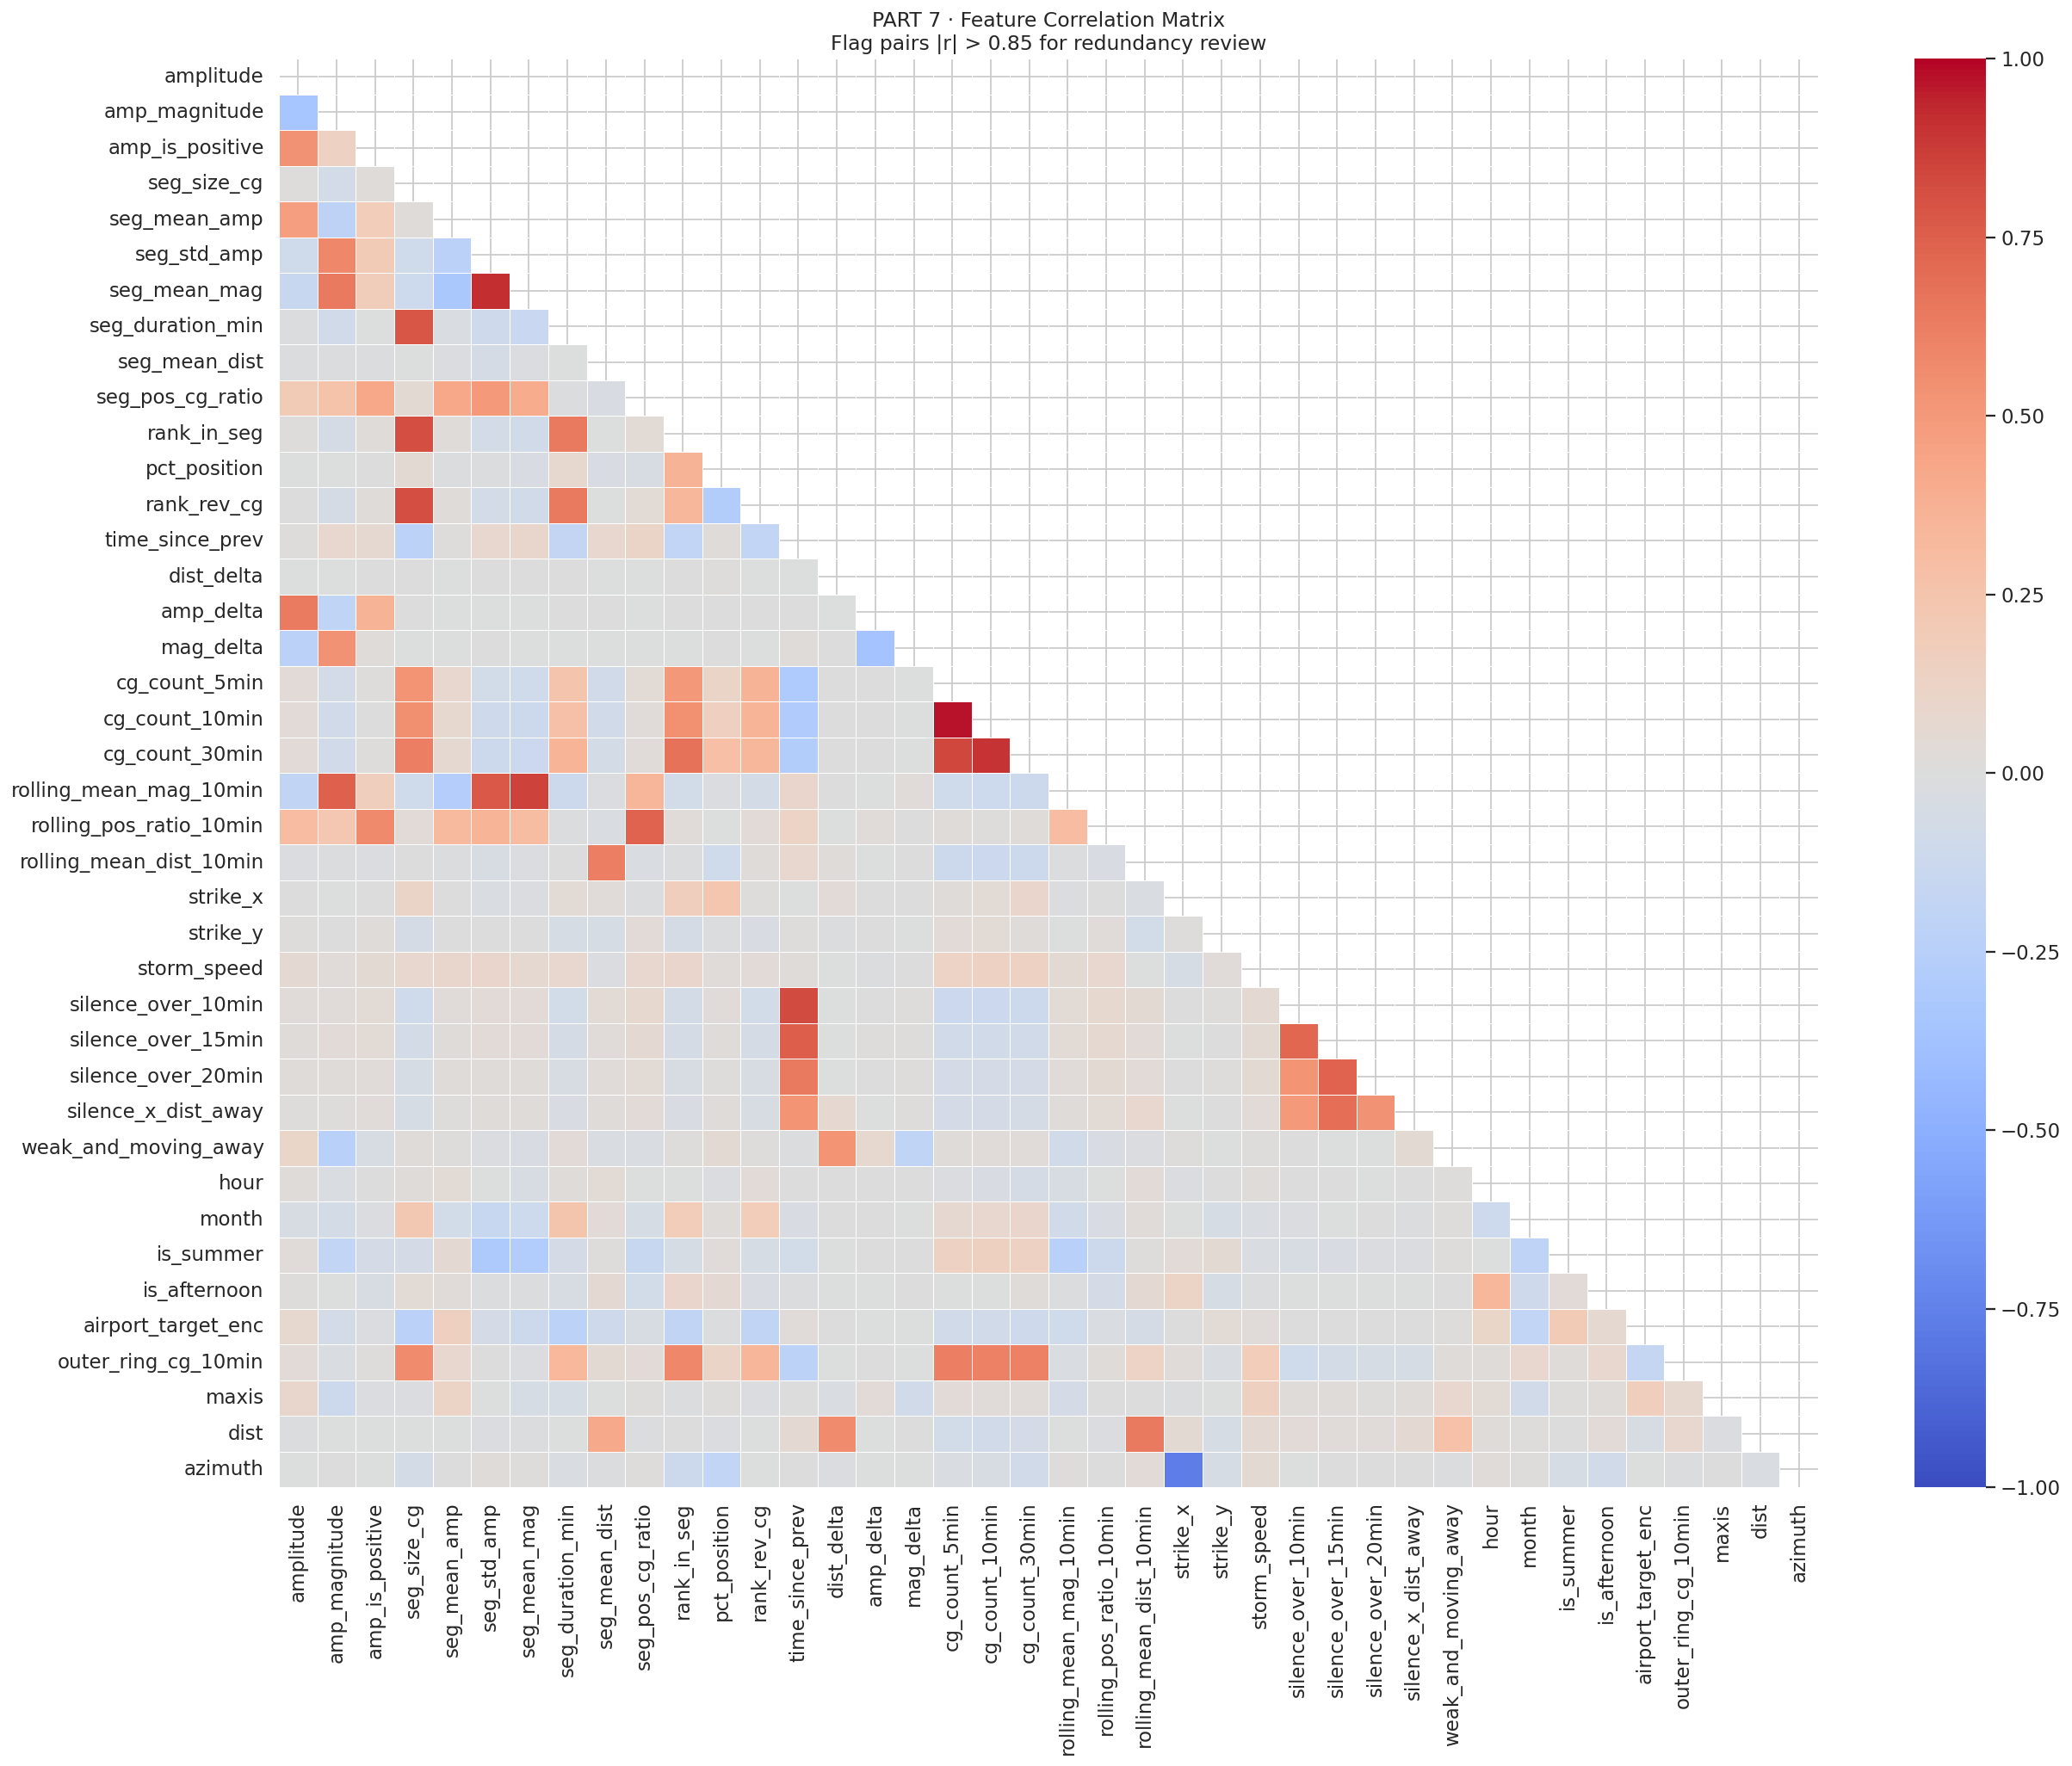

In [22]:
ENGINEERED_FEATURES = [
    # A: Amplitude decomposition
    "amplitude", "amp_magnitude", "amp_is_positive",
    # B: Segment aggregations
    "seg_size_cg", "seg_mean_amp", "seg_std_amp",
    "seg_mean_mag", "seg_duration_min", "seg_mean_dist",
    "seg_pos_cg_ratio",
    # C: Position
    "rank_in_seg", "pct_position", "rank_rev_cg",
    # D: Lag/delta
    "time_since_prev", "dist_delta", "amp_delta", "mag_delta",
    # E: Rolling
    "cg_count_5min", "cg_count_10min", "cg_count_30min",
    "rolling_mean_mag_10min", "rolling_pos_ratio_10min",
    "rolling_mean_dist_10min",
    # F: Cartesian
    "strike_x", "strike_y", "storm_speed",
    # G: Threshold
    "silence_over_10min", "silence_over_15min", "silence_over_20min",
    # H: Interaction
    "silence_x_dist_away", "weak_and_moving_away",
    # I: Calendar
    "hour", "month", "is_summer", "is_afternoon",
    # J: Airport
    "airport_target_enc",
    # K: Outer ring
    "outer_ring_cg_10min",
    # Raw
    "maxis", "dist", "azimuth",
]

corr = df_cg[ENGINEERED_FEATURES].corr()
high_corr_pairs = [
    (ENGINEERED_FEATURES[i], ENGINEERED_FEATURES[j],
     round(corr.iloc[i,j], 3))
    for i in range(len(ENGINEERED_FEATURES))
    for j in range(i+1, len(ENGINEERED_FEATURES))
    if abs(corr.iloc[i,j]) > 0.85
]

print("\n=== HIGH CORRELATION PAIRS (|r| > 0.85) ===")
if high_corr_pairs:
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"  {f1:35s} ↔ {f2:35s}  r={r:+.3f}")
else:
    print("  None — all features are weakly correlated ✅")

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax,
)
ax.set_title("PART 7 · Feature Correlation Matrix\n"
             "Flag pairs |r| > 0.85 for redundancy review",
             fontsize=13)
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p7_correlation_matrix.png")
plt.show()


=== FEATURE SIGNAL STRENGTH (correlation with target) ===
time_since_prev            0.2160
seg_duration_min           0.2153
silence_over_10min         0.1742
cg_count_5min              0.1614
cg_count_10min             0.1605
cg_count_30min             0.1566
silence_over_15min         0.1443
seg_size_cg                0.1429
outer_ring_cg_10min        0.1383
seg_pos_cg_ratio           0.1269
rank_rev_cg                0.1241
rank_in_seg                0.1100
storm_speed                0.1096
silence_x_dist_away        0.1088
silence_over_20min         0.1080
rolling_pos_ratio_10min    0.1074
seg_mean_dist              0.0968
seg_mean_mag               0.0939
rolling_mean_mag_10min     0.0867
rolling_mean_dist_10min    0.0741


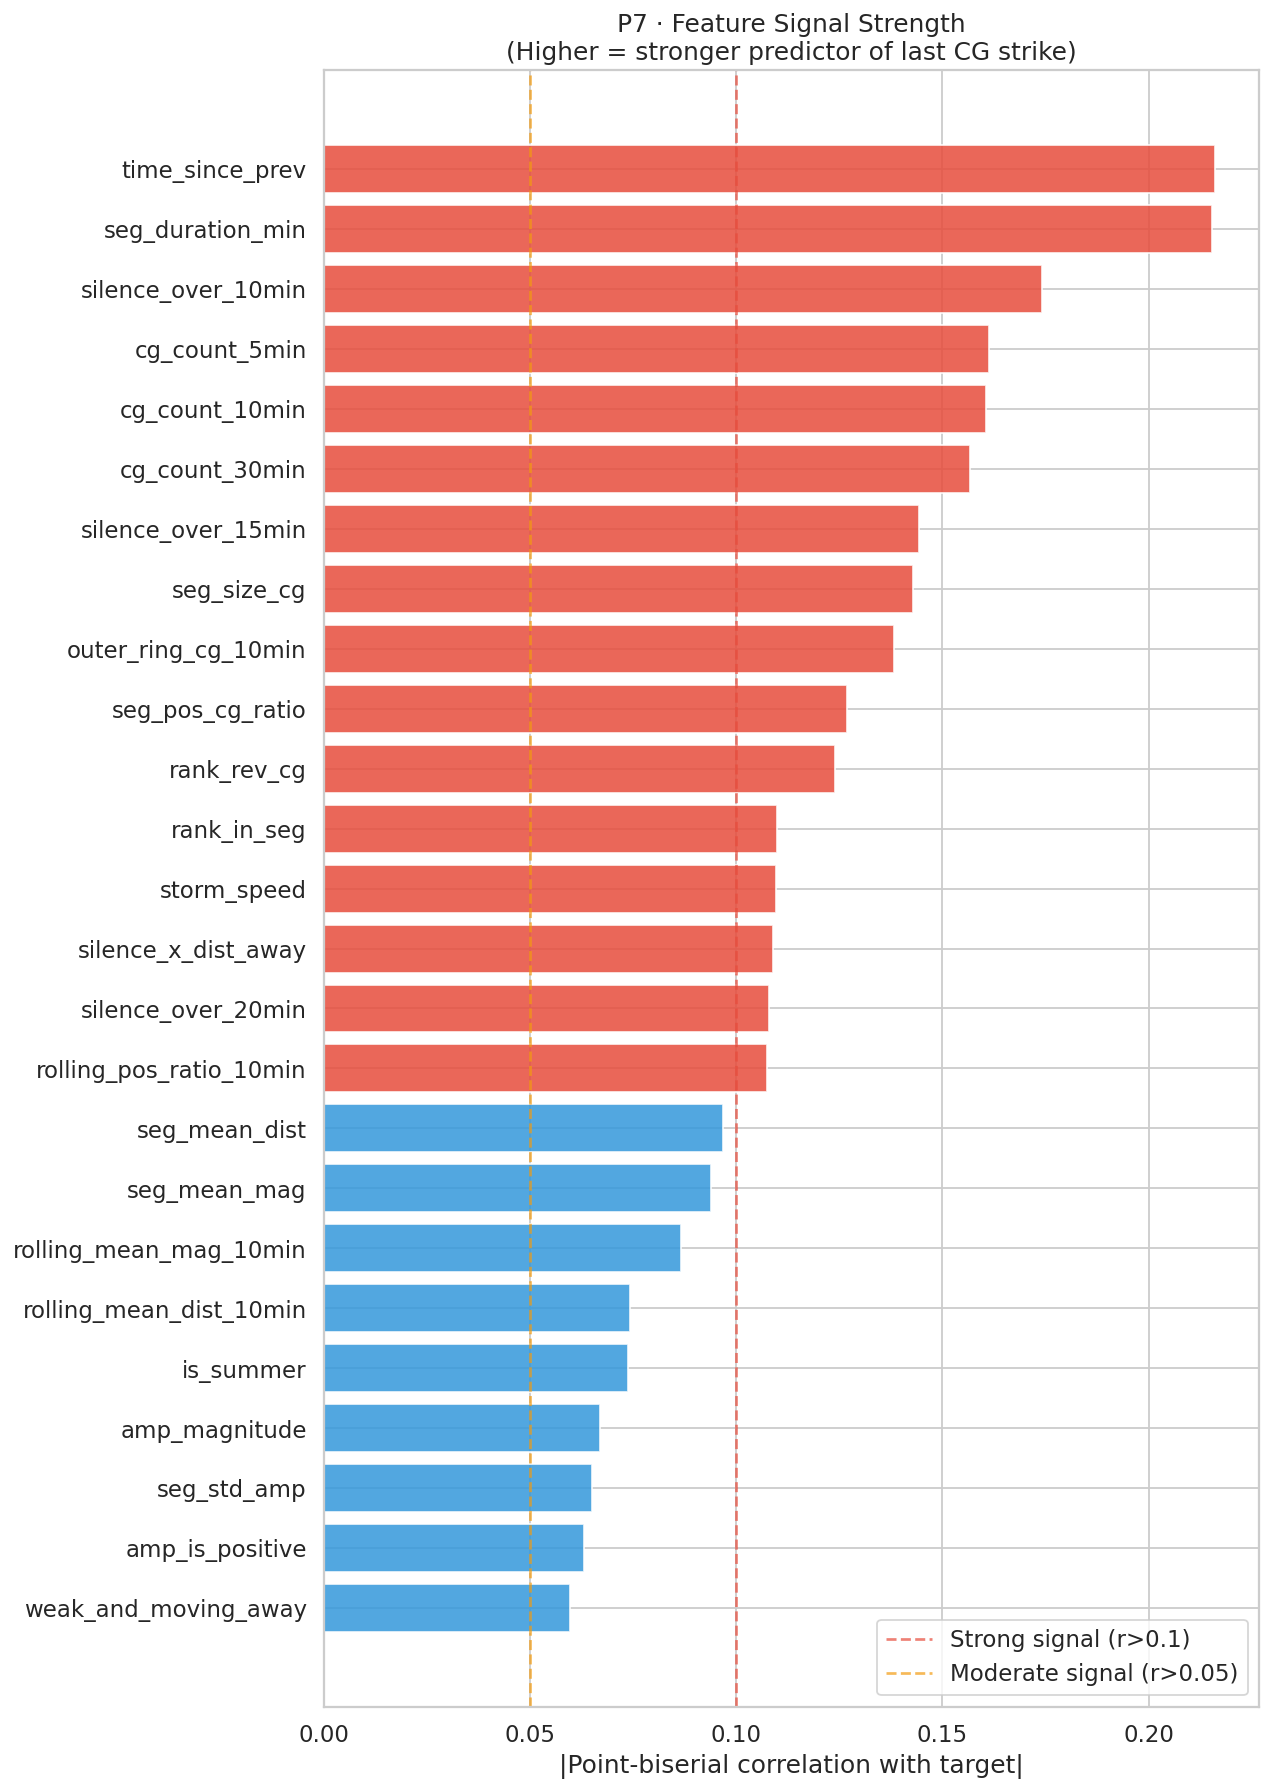

In [23]:
from scipy import stats

print("\n=== FEATURE SIGNAL STRENGTH (correlation with target) ===")
y_binary = df_cg["is_last_lightning_cloud_ground"].astype(int)
signal_scores = {}
for feat in ENGINEERED_FEATURES:
    try:
        vals = df_cg[feat].fillna(0)
        r, p = stats.pointbiserialr(y_binary, vals)
        signal_scores[feat] = abs(r)
    except Exception:
        pass

signal_df = pd.Series(signal_scores).sort_values(ascending=False)
print(signal_df.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 14))
top_features = signal_df.head(25)
colors = ["#E74C3C" if v > 0.1 else "#3498DB" if v > 0.05 else "#95A5A6"
          for v in top_features.values]
ax.barh(top_features.index[::-1], top_features.values[::-1],
        color=colors[::-1], edgecolor="white", alpha=0.85)
ax.axvline(0.1, color="#E74C3C", linestyle="--",
           alpha=0.7, label="Strong signal (r>0.1)")
ax.axvline(0.05, color="#F39C12", linestyle="--",
           alpha=0.7, label="Moderate signal (r>0.05)")
ax.set_xlabel("|Point-biserial correlation with target|")
ax.set_title("P7 · Feature Signal Strength\n"
             "(Higher = stronger predictor of last CG strike)")
ax.legend()
plt.tight_layout()
save_to_drive(fig, FIG_DIR / "p7_feature_signal_strength.png")
plt.show()

---
## PART 8 — Final Feature List & Saves

In [24]:
print("\n")
print("="*70)
print("  FINAL FEATURE LIST FOR MODEL TRAINING")
print("="*70)

FINAL_FEATURES = {
    "Amplitude decomposition": [
        "amplitude",          # raw with sign (negative=normal CG, positive=decay signal)
        "amp_magnitude",      # |amplitude| — intensity without sign confusion
        "amp_is_positive",    # binary: positive CG strikes signal storm decay
    ],
    "Segment context": [
        "seg_size_cg",        # how many CG strikes in this storm so far
        "seg_mean_mag",       # average amplitude magnitude of storm
        "seg_std_amp",        # variability of amplitude — erratic = weakening
        "seg_duration_min",   # how long storm has been active
        "seg_mean_dist",      # where storm is centered relative to airport
        "seg_pos_cg_ratio",   # fraction of positive CG in storm — decay indicator
    ],
    "Position within segment": [
        "rank_in_seg",        # ordinal position (0=first)
        "pct_position",       # normalized position (0=first, 1=last)
        "rank_rev_cg",        # reverse rank (0=last CG) — validated 1 True/segment
    ],
    "Temporal dynamics": [
        "time_since_prev",    # seconds since last CG — growing gap = ending
        "dist_delta",         # storm moving toward(−) or away(+) from airport
        "mag_delta",          # amplitude weakening(−) or strengthening(+)
        "storm_speed",        # how fast storm is moving across zone
    ],
    "Rolling activity": [
        "cg_count_10min",     # CG strikes in last 10 min — density dropping = ending
        "cg_count_30min",     # CG strikes in last 30 min — broader context
        "rolling_mean_mag_10min",    # recent amplitude trend
        "rolling_pos_ratio_10min",   # recent positive CG ratio — decay signal
        "rolling_mean_dist_10min",   # recent distance trend
    ],
    "Threshold / regime": [
        "silence_over_10min", # binary: gap > 10 min (unusual — storm maybe ending)
        "silence_over_15min", # binary: gap > 15 min (strong ending signal)
        "silence_over_20min", # binary: gap > 20 min (very strong ending signal)
    ],
    "Interaction": [
        "silence_x_dist_away",   # silence AND moving away — strongest end signal
        "weak_and_moving_away",  # weak amplitude AND moving away
    ],
    "Outer ring context": [
        "outer_ring_cg_10min",   # CG activity in 20-50km ring — storm fuel supply
    ],
    "Calendar": [
        "hour",           # time of day (afternoon = peak convection)
        "month",          # month (summer = Mediterranean storms)
        "is_summer",      # binary summer flag
        "is_afternoon",   # binary afternoon flag
    ],
    "Raw physical": [
        "maxis",          # flash energy/multiplicity index
        "dist",           # current distance from airport
        "azimuth",        # current direction to airport
        "strike_x",       # Cartesian east-west position
        "strike_y",       # Cartesian north-south position
    ],
    "Airport": [
        "airport_target_enc",  # target-encoded mean positive rate per airport
        # airport_cat is set at model training time, not saved to CSV
    ],
}

total = 0
for group, feats in FINAL_FEATURES.items():
    print(f"\n  {group} ({len(feats)} features):")
    for f in feats:
        print(f"    • {f}")
    total += len(feats)

print(f"\n  TOTAL FEATURES: {total}")
print(f"\n  VALIDATION STRATEGY:")
print(f"    Primary  : GroupKFold(n_splits=5, groups=segment_key)")
print(f"    Secondary: Temporal split (train ≤ 2020, val ≥ 2021)")
print(f"    Stress   : Leave-one-airport-out (2-3 airports)")
print(f"\n  IMBALANCE HANDLING:")
print(f"    scale_pos_weight = {ratio}")
print(f"\n  MODEL METRIC TARGETS:")
print(f"    Rule baseline F1    : {rule_f1:.4f}")
print(f"    Rule baseline AUC   : {rule_auc:.4f}")
print(f"    Rule baseline Brier : {rule_brier:.4f}")
print(f"    ML model must beat all three.")
print("="*70)



  FINAL FEATURE LIST FOR MODEL TRAINING

  Amplitude decomposition (3 features):
    • amplitude
    • amp_magnitude
    • amp_is_positive

  Segment context (6 features):
    • seg_size_cg
    • seg_mean_mag
    • seg_std_amp
    • seg_duration_min
    • seg_mean_dist
    • seg_pos_cg_ratio

  Position within segment (3 features):
    • rank_in_seg
    • pct_position
    • rank_rev_cg

  Temporal dynamics (4 features):
    • time_since_prev
    • dist_delta
    • mag_delta
    • storm_speed

  Rolling activity (5 features):
    • cg_count_10min
    • cg_count_30min
    • rolling_mean_mag_10min
    • rolling_pos_ratio_10min
    • rolling_mean_dist_10min

  Threshold / regime (3 features):
    • silence_over_10min
    • silence_over_15min
    • silence_over_20min

  Interaction (2 features):
    • silence_x_dist_away
    • weak_and_moving_away

  Outer ring context (1 features):
    • outer_ring_cg_10min

  Calendar (4 features):
    • hour
    • month
    • is_summer
    • is_afterno

In [25]:
feature_doc = pd.DataFrame([
    {"group": g, "feature": f,
     "signal_strength": round(signal_scores.get(f, 0), 4)}
    for g, feats in FINAL_FEATURES.items()
    for f in feats
])
feature_doc = feature_doc.sort_values(
    ["group","signal_strength"], ascending=[True, False]
)

save_to_drive(df_cg.drop(columns=["airport_cat"], errors="ignore"),
              SAVES_DIR / "df_cg_all_features.csv")
save_to_drive(seg_stats,    SAVES_DIR / "segment_stats_final.csv")
save_to_drive(feature_doc,  SAVES_DIR / "feature_list_final.csv")
save_to_drive(
    pd.DataFrame([{
        "total_rows":          len(df),
        "inside_zone_rows":    len(df_inside),
        "outside_zone_rows":   len(df_outside),
        "cg_rows":             len(df_cg),
        "true_count":          int(pos),
        "false_count":         int(neg),
        "imbalance_ratio":     int(ratio),
        "scale_pos_weight":    int(ratio),
        "n_segments":          len(seg_stats),
        "n_airports":          seg_stats["airport"].nunique(),
        "rule_f1":             round(rule_f1, 4),
        "rule_auc":            round(rule_auc, 4),
        "rule_brier":          round(rule_brier, 4),
        "total_features":      total,
    }]),
    SAVES_DIR / "eda_final_summary.csv"
)

log.info("All EDA outputs saved to Drive.")
print(f"\n✅ EDA complete. All files saved to {SAVES_DIR}")


✅ EDA complete. All files saved to /content/drive/MyDrive/databattle2026/outputs/saves
